In [1]:
import pandas as pd

xls = pd.read_excel(
    '../ParleysRWIS_20211101-20230430.xlsx',
    sheet_name=['RwisAtmosphericData', 'RwisSurfaceData'],
    parse_dates=['SampleTime'],    # ← ensure this column is parsed as full datetime
    engine='openpyxl'
)

df1 = xls['RwisAtmosphericData']
df2 = xls['RwisSurfaceData']

# merge
df1['SampleTime'] = pd.to_datetime(df1['SampleTime'])
df2['SampleTime'] = pd.to_datetime(df2['SampleTime'])

df1['RwisControllerIntId'] = df1['RwisControllerIntId'].astype(str)
df2['RwisControllerIntId'] = df2['RwisControllerIntId'].astype(str)

df_merged = pd.merge(
    df1,
    df2,
    on=['SampleTime', 'RwisControllerIntId'],
    how='inner',
    suffixes=('_atm','_surf')
)



In [2]:
cols_to_drop = ['Pressure', 'SnowIntervalDepth', 'PrecipitationIntervalAmount','PrecipitationAmount',
                'RoadStatusText','iceCurCondIndex','iceAvgCondIndex','iceCurCondCode','iceAvgCondCode',
               'iceCurFricIndex','iceAvgFricIndex','iceCurFricCode','iceAvgFricCode','iceGrip','iceXValue',
               'iceYValue','iceYXRatio','iceLens','SurfaceSensorError','SurfaceSalinity','SurfaceFreezePoint','RoadStatus',
               'RoadStatus','RoadTemp','iceRoadTemp','RwisAtmoEquipmentIntId','WindSpeedGustTimestamp',
               'RwisSurfaceEquipmentIntId','WindDirection','WindSpeedAverage','WindSpeedGust','Visibility',
                'BatteryVoltage','dstInputVoltage','dstHardwareStatus','SurfaceStatusText','dscRoadStatusText','SubSurfaceTemp',
               'AirTemp_atm','DewPoint_atm','RelativeHumidity_atm','dscLevelOfGrip','dstRoadTemp'] 
df_merged_1 = df_merged.drop(columns=cols_to_drop)
df_merged_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 510142 entries, 0 to 510141
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              510142 non-null  datetime64[ns]
 1   RwisControllerIntId     510142 non-null  object        
 2   PrecipitationIntensity  45706 non-null   object        
 3   SnowDepth               115089 non-null  float64       
 4   SolarRadiation          434049 non-null  float64       
 5   PrecipitationType       508441 non-null  object        
 6   WetBulbTemp             509154 non-null  float64       
 7   SnowfallRate            510142 non-null  float64       
 8   WinterRoadWeatherIndex  503682 non-null  float64       
 9   RainTotal               510142 non-null  float64       
 10  StormIntensityIndex     500135 non-null  float64       
 11  PerformanceMetric       503605 non-null  float64       
 12  SurfaceStatus           506373

0.00    474621
0.01      7009
0.02       962
0.03       838
0.04       771
0.05       596
0.06       400
0.07       302
0.10       275
0.08       253
0.09       250
0.12       222
0.11       208
0.13       190
0.14       186
0.15       179
0.16       166
0.18       151
0.17       148
0.19       143
0.20       136
0.21       127
0.24       115
0.22       113
0.23       111
0.25       100
0.28       100
0.26        96
0.30        94
0.31        89
0.32        88
0.27        84
0.37        77
0.39        77
0.35        73
0.29        73
0.36        71
0.38        66
0.34        65
0.33        61
0.40        59
0.41        56
0.43        52
0.44        52
0.42        49
0.47        43
0.50        42
0.45        41
0.49        36
0.48        36
0.51        36
0.55        35
0.70        35
0.64        35
0.72        35
0.52        35
0.58        34
0.60        33
0.74        33
0.53        32
0.62        32
1.05        31
0.68        30
0.56        30
0.65        29
0.98        29
0.54      

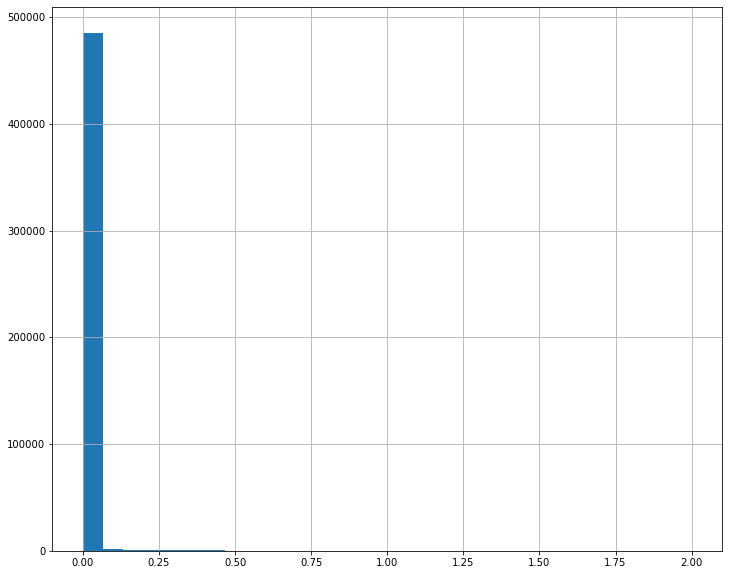

In [3]:
# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

# Remove rows where PrecipitationIntensity is 'fog'
df_merged_1 = df_merged_1[df_merged_1['PrecipitationIntensity'] != 'fog']
# Remove rows where WetBulbTemp < -100
df_merged_1 = df_merged_1[df_merged_1['WetBulbTemp'] >= -100]
df_merged_1 = df_merged_1[df_merged_1['SurfaceTemp'] < 200]
df_merged_1 = df_merged_1[df_merged_1['AirTemp_surf'] < 100]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] < 80]
df_merged_1 = df_merged_1[df_merged_1['DewPoint_surf'] > -20]
df_merged_1 = df_merged_1[df_merged_1['dscSurfStatus'] < 10]
df_merged_1 = df_merged_1[df_merged_1['RainTotal'] <= 0.1]
df_merged_1 = df_merged_1[df_merged_1['SnowfallRate'] <= 3]
df_merged_1 = df_merged_1[df_merged_1['WinterRoadWeatherIndex'] <= 1.6]
df_merged_1 = df_merged_1[df_merged_1['StormIntensityIndex'] <= 2.2]
df_merged_1 = df_merged_1[df_merged_1['SurfaceWaterDepth'] <= 2]
df_merged_1 = df_merged_1[df_merged_1['SurfaceIceDepth'] <= 0.4]
df_merged_1 = df_merged_1[df_merged_1['SurfaceSnowDepth'] <= 2]
df_merged_1 = df_merged_1.fillna(df_merged_1.mean(numeric_only=True))

df_merged_1 = df_merged_1[
    (df_merged_1['SurfaceGrip'] >= 0) &
    (df_merged_1['SurfaceGrip'] <= 1)
].reset_index(drop=True)


df_merged_1['SurfaceSnowDepth'].hist(bins=30, figsize=(12, 10))
# Show all value counts for SnowfallRate
# print(df_merged_1['SnowfallRate'].value_counts(dropna=False, sort=True).to_string())
print(df_merged_1['SurfaceSnowDepth'].value_counts(dropna=False, sort=True).to_string())

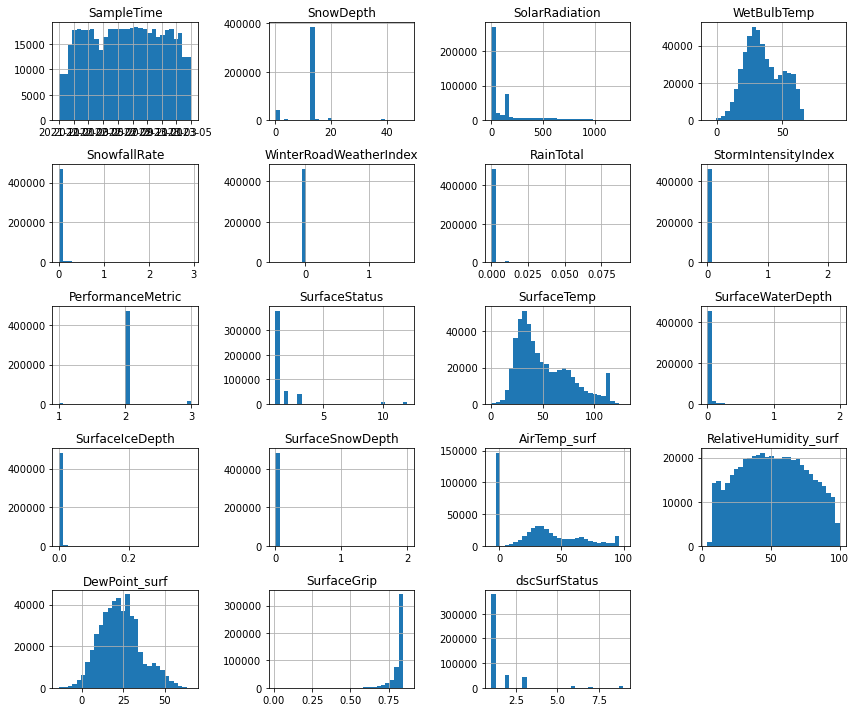

In [4]:
# Cell 4: histograms for all numeric columns
import matplotlib.pyplot as plt
%matplotlib inline

df_merged_1.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

## make sure time_diff is the same

In [5]:
df_merged_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492011 entries, 0 to 492010
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SampleTime              492011 non-null  datetime64[ns]
 1   RwisControllerIntId     492011 non-null  object        
 2   PrecipitationIntensity  43029 non-null   object        
 3   SnowDepth               492011 non-null  float64       
 4   SolarRadiation          492011 non-null  float64       
 5   PrecipitationType       491376 non-null  object        
 6   WetBulbTemp             492011 non-null  float64       
 7   SnowfallRate            492011 non-null  float64       
 8   WinterRoadWeatherIndex  492011 non-null  float64       
 9   RainTotal               492011 non-null  float64       
 10  StormIntensityIndex     492011 non-null  float64       
 11  PerformanceMetric       492011 non-null  float64       
 12  SurfaceStatus           492011

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# === 1. Load & Prepare Data (assuming already merged into df_merged) ===
# We assume df_merged is available in the environment.

# Sort and compute time differences
df = df_merged_1.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df['time_diff'] = df.groupby('RwisControllerIntId')['SampleTime'].diff()

mask_drop5 = (
    (df['time_diff'] == pd.Timedelta(minutes=5)) &
    (df['SampleTime'].dt.minute % 10 == 5)
)

df2 = df[~mask_drop5].reset_index(drop=True)
df2 = df2.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)
df2['time_diff'] = df2.groupby('RwisControllerIntId')['SampleTime'].diff()

df10 = df2[df2['time_diff'] == pd.Timedelta(minutes=10)].reset_index(drop=True)

# === 2. One-hot encoding of categorical columns ===
cat_cols = [
    'PrecipitationIntensity',
    'PrecipitationType',
#     'SurfaceStatusText',
#     'dscRoadStatusText'
]
df_encoded = pd.get_dummies(df10, columns=cat_cols)

# === 3. Define features and label ===
label_col = 'SurfaceGrip'
feature_cols = df_encoded.columns.drop(['SampleTime', 'RwisControllerIntId', 'time_diff', label_col]).tolist()


# === 4. Normalize features ===
scaler = MinMaxScaler()
df_encoded[feature_cols] = scaler.fit_transform(df_encoded[feature_cols])

# === 5. Construct dataset ===
def build_rnn_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    """
    构建 RNN 用的数据：
    - 输入：前 window 步的 (X + y)，再加上当前步的 X 和 t-1 的 y
    - 输出：当前步的 y
    """
    X_seq, y_seq = [], []
    df = df.sort_values(['RwisControllerIntId', 'SampleTime']).reset_index(drop=True)

    grouped = df.groupby('RwisControllerIntId')
    for _, group in grouped:
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            hist = group.iloc[i - window:i]
            target = group.iloc[i]

            hist_features = hist[feature_cols].values          # shape: (window, F)
            hist_labels = hist[[label_col]].values             # shape: (window, 1)
            hist_combined = np.hstack([hist_features, hist_labels])  # shape: (window, F+1)

            curr_features = target[feature_cols].values.reshape(1, -1)  # shape: (1, F)
            prev_y = hist_labels[-1:]  # shape: (1, 1), 即 t-1 的 y
            curr_combined = np.hstack([curr_features, prev_y])         # shape: (1, F+1)

            seq = np.vstack([hist_combined, curr_combined])    # shape: (window + 1, F+1)
            X_seq.append(seq)
            y_seq.append(target[label_col])

    return np.array(X_seq), np.array(y_seq)



def build_tabular_dataset(df, feature_cols, label_col='SurfaceGrip', window=10):
    X_tab = []
    y_tab = []

    grouped = df.sort_values(['RwisControllerIntId', 'SampleTime']).groupby('RwisControllerIntId')
    for _, group in grouped:
        group = group.reset_index(drop=True)
        for i in range(window, len(group)):
            target = group.iloc[i]
            X_tab.append(target[feature_cols].values)
            y_tab.append(target[label_col])
    return np.array(X_tab), np.array(y_tab)


X_seq, y = build_rnn_dataset(df_encoded, feature_cols, label_col='SurfaceGrip', window=10)
X_tab, _ = build_tabular_dataset(df_encoded, feature_cols, label_col='SurfaceGrip', window=10)

# # === 6. Train-test split ===
# X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
#     X_seq, X_tab, y, test_size=0.2, random_state=42
# )

# === 7. Evaluation function ===
def evaluate_model(y_true, y_pred, bins=np.arange(0.0, 1.01, 0.1)):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    metrics = pd.DataFrame({
        'Metric': ['MSE','MAE','MAPE','R2'],
        'Value': [mse, mae, mape, r2]
    }).set_index('Metric')
    print("Overall Metrics:")
    display(metrics.style.format({'Value':'{:.4f}'}))

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn,mx],[mn,mx],'r--', linewidth=1)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title('True vs Predicted')
    plt.tight_layout()
    plt.show()

    labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, labels=labels, include_lowest=True)

    seg_results = []
    for lbl in labels:
        sub = df_eval[df_eval['bin'] == lbl]
        count = len(sub)
        seg_r2 = r2_score(sub['y_true'], sub['y_pred']) if count >= 2 else np.nan
        seg_results.append({'Interval': lbl, 'Count': count, 'R2': seg_r2})

    seg_df = pd.DataFrame(seg_results).set_index('Interval')
    avg_r2 = seg_df['R2'].mean(skipna=True)

    print("\nSegmented R² by True-Value Bin:")
    display(seg_df.style.format({'Count':'{:.0f}','R2':'{:.4f}'}))
    print(f"Average segmented R²: {avg_r2:.4f}")

    fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, lbl in zip(axes, labels):
        sub = df_eval[df_eval['bin'] == lbl]
        ax.scatter(sub['y_true'], sub['y_pred'], alpha=0.5, s=10)
        ax.plot([0,1],[0,1],'r--', linewidth=1)
        ax.set_title(lbl)
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.set_xlabel('True')
        ax.set_ylabel('Pred')
    for ax in axes[len(labels):]:
        ax.axis('off')
    plt.suptitle('Segmented True vs Pred by Bin', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# return final dataset shapes for confirmation
X_seq.shape, X_tab.shape, y.shape




((276848, 11, 24), (276848, 23), (276848,))

## generate train and test data for time-series model and machine learning model

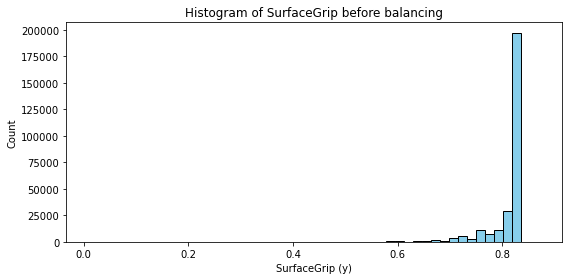

In [7]:
# === 分布可视化（清洗前） ===
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("SurfaceGrip (y)")
plt.ylabel("Count")
plt.title("Histogram of SurfaceGrip before balancing")
plt.tight_layout()
plt.show()

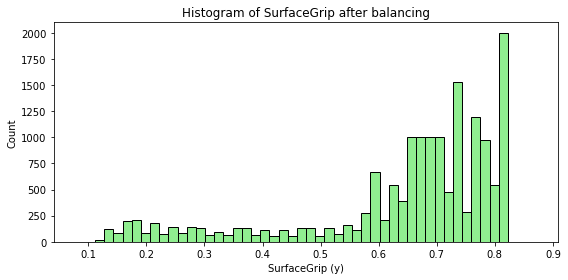

X_seq: (13004, 11, 24) X_tab: (13004, 23) y: (13004,)


In [8]:
def balance_y_distribution(X_seq, X_tab, y, bins=50, max_per_bin=1000, random_state=43):
    np.random.seed(random_state)
    bin_edges = np.linspace(np.min(y), np.max(y), bins + 1)
    bin_indices = np.digitize(y, bins=bin_edges, right=True)

    selected_indices = []
    for b in range(1, bins + 1):
        bin_mask = bin_indices == b
        idx_in_bin = np.where(bin_mask)[0]
        if len(idx_in_bin) > max_per_bin:
            idx_selected = np.random.choice(idx_in_bin, size=max_per_bin, replace=False)
        else:
            idx_selected = idx_in_bin
        selected_indices.extend(idx_selected)

    selected_indices = np.array(selected_indices)
    return (
        X_seq[selected_indices],
        X_tab[selected_indices],
        y[selected_indices]
    )

# === 应用均衡 ===
X_seq_bal, X_tab_bal, y_bal = balance_y_distribution(X_seq, X_tab, y, bins=50, max_per_bin=1000)

# === 分布可视化（均衡后） ===
plt.figure(figsize=(8, 4))
plt.hist(y_bal, bins=50, color='lightgreen', edgecolor='black')
plt.xlabel("SurfaceGrip (y)")
plt.ylabel("Count")
plt.title("Histogram of SurfaceGrip after balancing")
plt.tight_layout()
plt.show()

# === Train-test split ===
X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_seq_bal, X_tab_bal, y_bal, test_size=0.2, random_state=43
)

# 最终维度确认
print("X_seq:", X_seq_train.shape, "X_tab:", X_tab_train.shape, "y:", y_train.shape)


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, bins=np.arange(0.0, 1.01, 0.1)):
    # === Overall metrics ===
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    metrics = pd.DataFrame({
        'Metric': ['MSE','MAE','MAPE','R2'],
        'Value': [mse, mae, mape, r2]
    }).set_index('Metric')
    print("Overall Metrics:")
    display(metrics.style.format({'Value':'{:.4f}'}))

    # === Scatter Plot ===
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn,mx],[mn,mx],'r--', linewidth=1)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title('True vs Predicted')
    plt.tight_layout()
    plt.show()

    # === Segmented Evaluation ===
    labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df_eval['bin'] = pd.cut(df_eval['y_true'], bins=bins, labels=labels, include_lowest=True)

    seg_results = []
    for lbl in labels:
        sub = df_eval[df_eval['bin'] == lbl]
        count = len(sub)
        if count >= 2:
            r2_val   = r2_score(sub['y_true'], sub['y_pred'])
            mse_val  = mean_squared_error(sub['y_true'], sub['y_pred'])
            mae_val  = mean_absolute_error(sub['y_true'], sub['y_pred'])
            mape_val = mean_absolute_percentage_error(sub['y_true'], sub['y_pred'])
        else:
            r2_val = mse_val = mae_val = mape_val = np.nan
        seg_results.append({
            'Interval': lbl, 'Count': count,
            'R2': r2_val, 'MSE': mse_val,
            'MAE': mae_val, 'MAPE': mape_val
        })

    seg_df = pd.DataFrame(seg_results).set_index('Interval')
    print("\nSegmented Metrics by True-Value Bin:")
    display(seg_df.style.format({'Count': '{:.0f}', 'R2': '{:.4f}', 'MSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.4f}'}))

    print(f"\nAverage Segmented Metrics (skip NaN):")
    print(f"  R2:   {seg_df['R2'].mean(skipna=True):.4f}")
    print(f"  MSE:  {seg_df['MSE'].mean(skipna=True):.4f}")
    print(f"  MAE:  {seg_df['MAE'].mean(skipna=True):.4f}")
    print(f"  MAPE: {seg_df['MAPE'].mean(skipna=True):.4f}")

    # === Segment Scatter Plots ===
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, lbl in zip(axes, labels):
        sub = df_eval[df_eval['bin'] == lbl]
        ax.scatter(sub['y_true'], sub['y_pred'], alpha=0.5, s=10)
        ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
        ax.set_title(lbl)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('True')
        ax.set_ylabel('Pred')
    for ax in axes[len(labels):]:
        ax.axis('off')
    plt.suptitle('Segmented True vs Pred by Bin', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()



--- RandomForest ---
Overall Metrics:


,Value
Metric,
MSE,0.0049
MAE,0.0542
MAPE,0.1267
R2,0.8325


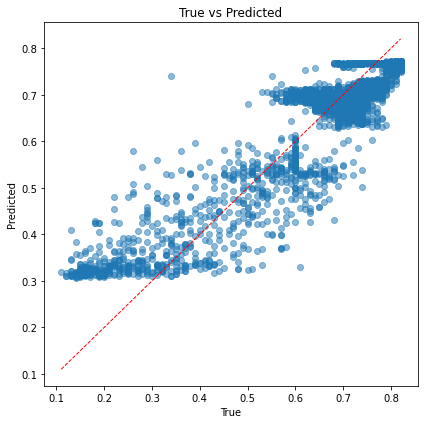


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-70.3047,0.0292,0.1684,1.0730
0.2-0.3,144,-16.3279,0.0148,0.1105,0.4646
0.3-0.4,131,-8.9883,0.0073,0.0590,0.1719
0.4-0.5,130,-4.2445,0.0054,0.0620,0.1367
0.5-0.6,180,-10.6497,0.0085,0.0748,0.1332
0.6-0.7,1009,-2.7154,0.0036,0.0452,0.0702
0.7-0.8,1014,-3.0962,0.0024,0.0403,0.0539
0.8-0.9,527,-42.2261,0.0023,0.0475,0.0584



Average Segmented Metrics (skip NaN):
  R2:   -19.8191
  MSE:  0.0092
  MAE:  0.0760
  MAPE: 0.2702


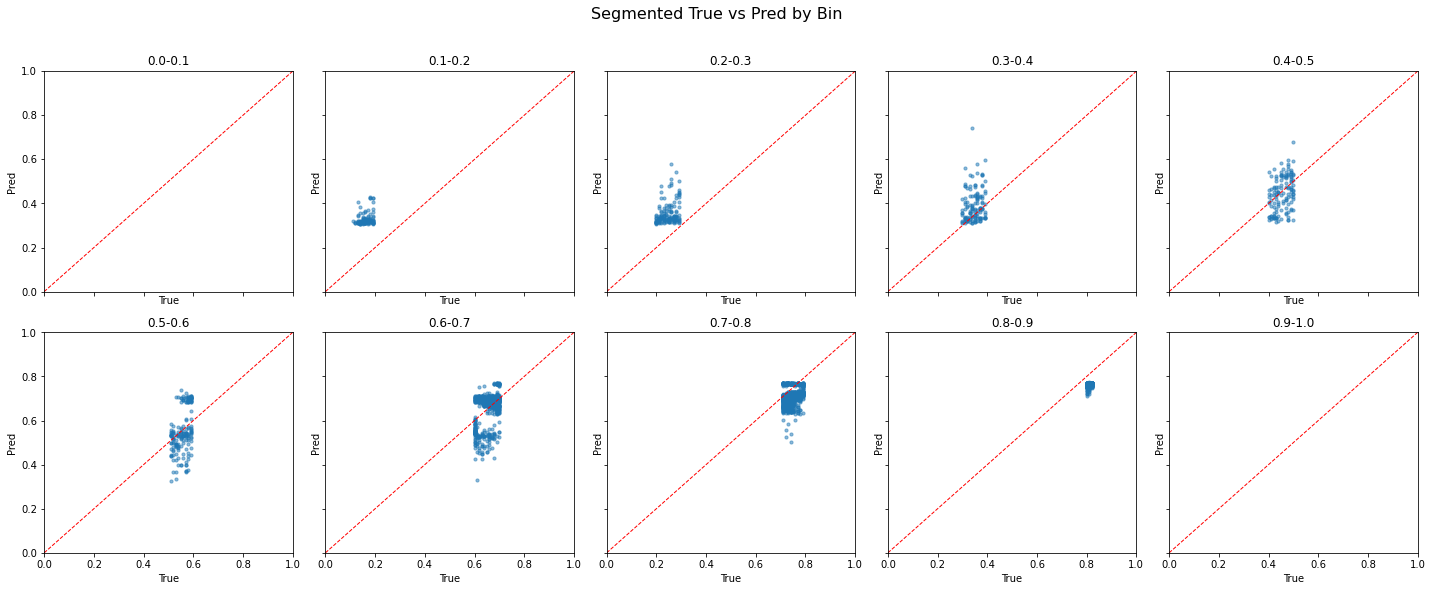


--- DecisionTree ---
Overall Metrics:


,Value
Metric,
MSE,0.0101
MAE,0.0682
MAPE,0.1705
R2,0.6549


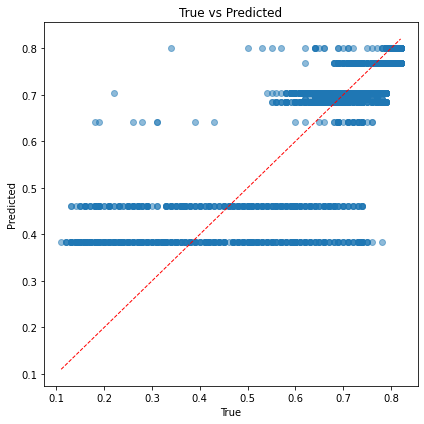


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-150.8518,0.0623,0.2457,1.5552
0.2-0.3,144,-36.4340,0.0319,0.1698,0.7150
0.3-0.4,131,-12.0420,0.0096,0.0754,0.2234
0.4-0.5,130,-3.2197,0.0043,0.0514,0.1118
0.5-0.6,180,-22.8768,0.0174,0.1255,0.2249
0.6-0.7,1009,-8.5385,0.0092,0.0646,0.1009
0.7-0.8,1014,-9.8896,0.0065,0.0525,0.0702
0.8-0.9,527,-12.6538,0.0007,0.0213,0.0261



Average Segmented Metrics (skip NaN):
  R2:   -32.0633
  MSE:  0.0177
  MAE:  0.1008
  MAPE: 0.3785


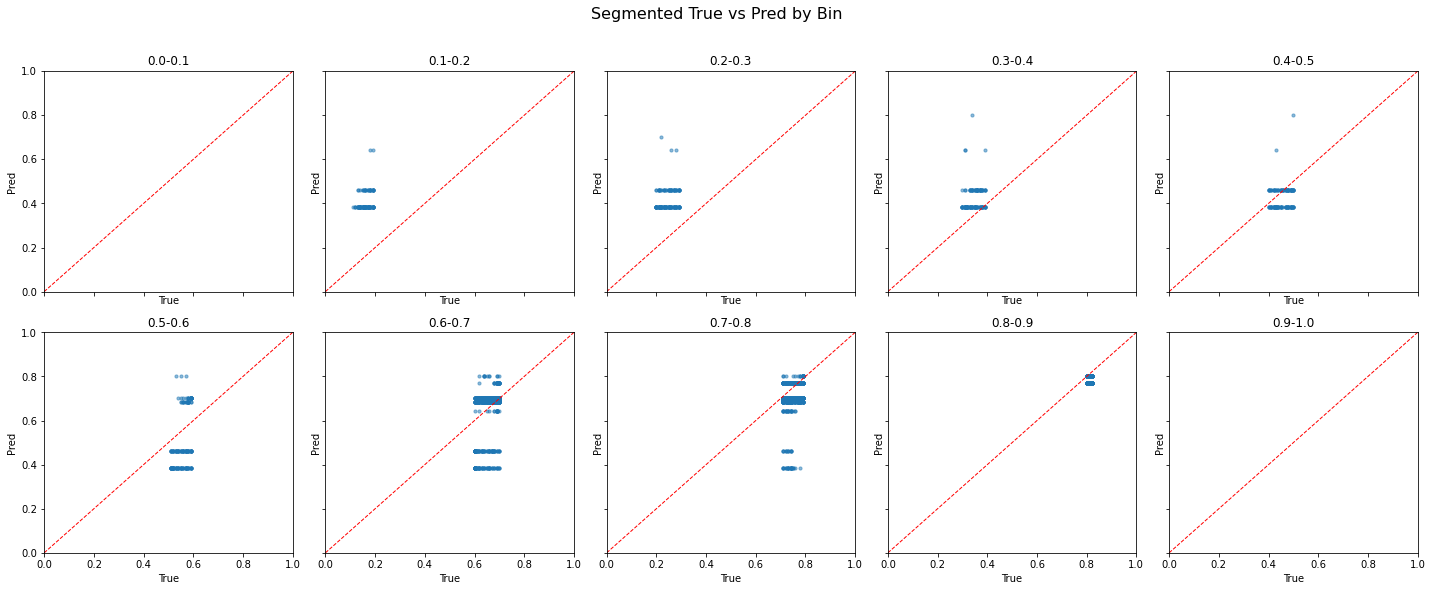


--- XGBoost ---
Overall Metrics:


,Value
Metric,
MSE,0.0014
MAE,0.0251
MAPE,0.0551
R2,0.9524


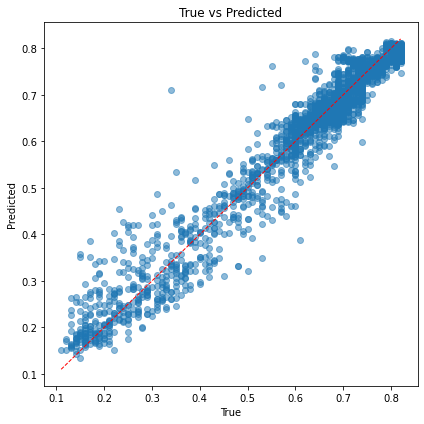


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-10.5817,0.0048,0.0502,0.3173
0.2-0.3,144,-3.8774,0.0042,0.0454,0.1874
0.3-0.4,131,-5.5723,0.0048,0.0534,0.1568
0.4-0.5,130,-1.9081,0.0030,0.0406,0.0901
0.5-0.6,180,-2.9769,0.0029,0.0382,0.0688
0.6-0.7,1009,-0.0677,0.0010,0.0230,0.0352
0.7-0.8,1014,0.0643,0.0006,0.0171,0.0231
0.8-0.9,527,-8.0242,0.0005,0.0180,0.0221



Average Segmented Metrics (skip NaN):
  R2:   -4.1180
  MSE:  0.0027
  MAE:  0.0357
  MAPE: 0.1126


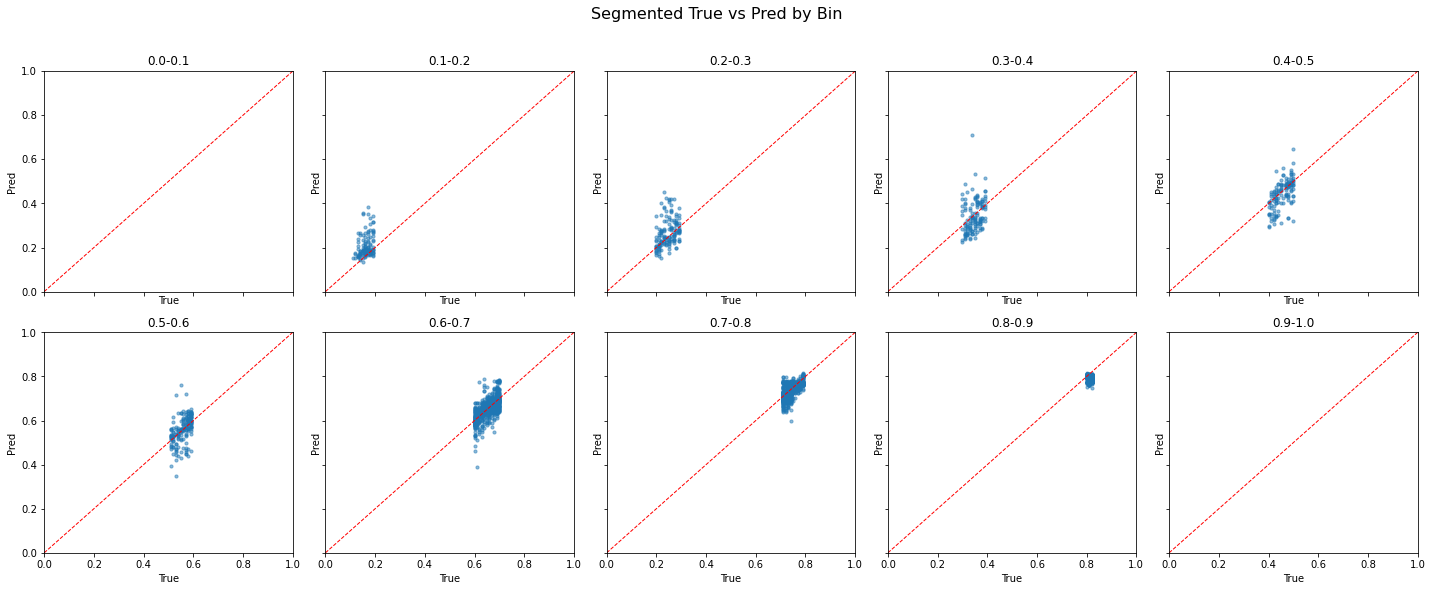


--- ANN (MLP) ---
Overall Metrics:


,Value
Metric,
MSE,0.0022
MAE,0.0302
MAPE,0.0702
R2,0.9241


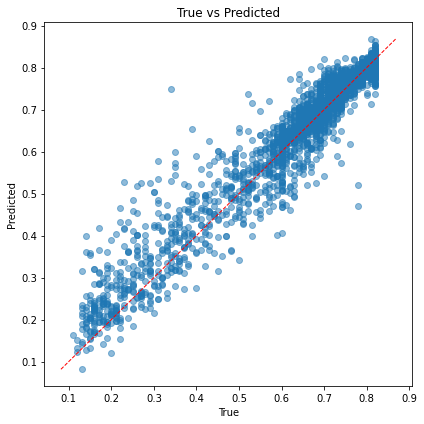


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-17.7920,0.0077,0.0692,0.4361
0.2-0.3,144,-8.9821,0.0085,0.0668,0.2755
0.3-0.4,131,-11.6209,0.0092,0.0696,0.2045
0.4-0.5,130,-4.3298,0.0055,0.0595,0.1316
0.5-0.6,180,-3.3808,0.0032,0.0428,0.0771
0.6-0.7,1009,-0.6815,0.0016,0.0295,0.0452
0.7-0.8,1014,-0.3403,0.0008,0.0185,0.0250
0.8-0.9,527,-6.0087,0.0004,0.0142,0.0174



Average Segmented Metrics (skip NaN):
  R2:   -6.6420
  MSE:  0.0046
  MAE:  0.0463
  MAPE: 0.1516


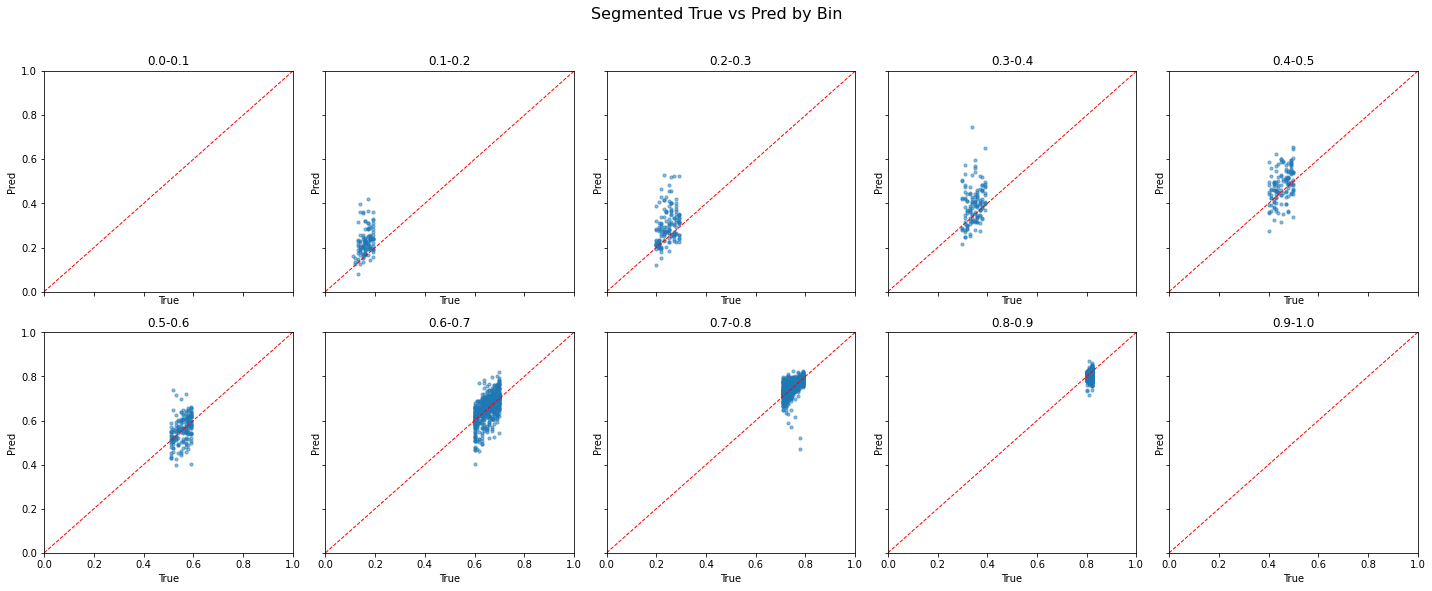

In [10]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# 假定 X_seq, X_tab, y, evaluate_model 都已在环境中定义好，且 df10 已无 NaN

# # 1）统一划分训练/测试集（RNN 和 Tabular 都用相同的 split）
# X_seq_train, X_seq_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
#     X_seq, X_tab, y, test_size=0.2, random_state=42
# )

# 2）定义并训练四个 Tabular 模型
tab_models = {
    'RandomForest': RandomForestRegressor(    n_estimators=100,
    max_depth=3,                 # limit depth
    min_samples_split=20,   
    min_samples_leaf=10,  
    max_features='sqrt',    
    random_state=43),
    'DecisionTree': DecisionTreeRegressor( 
        max_depth=3,       
    min_samples_split=20,     
    min_samples_leaf=10,    
    max_features='sqrt',  
    random_state=43),
    'XGBoost':      XGBRegressor(    n_estimators=200,
    learning_rate=0.1,         
    max_depth=2,        
    subsample=0.8,  
    colsample_bytree=0.7,    
    min_child_weight=10,    
    reg_alpha=1,  
    reg_lambda=5,
    objective='reg:squarederror',
    random_state=43),
    'ANN (MLP)':    MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                                 solver='adam', max_iter=200, random_state=43)
}

for name, model in tab_models.items():
    print(f"\n--- {name} ---")
    # 直接用 X_tab_train, y_train，因为已经无 NaN
    model.fit(X_tab_train, y_train)
    y_pred = model.predict(X_tab_test)
    evaluate_model(y_test, y_pred)




--- Simple RNN ---
Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-07-02 14:39:09.656139: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


407/407 - 1s - loss: 0.0173 - 1s/epoch - 3ms/step
Epoch 2/200
407/407 - 1s - loss: 0.0040 - 825ms/epoch - 2ms/step
Epoch 3/200
407/407 - 1s - loss: 0.0033 - 862ms/epoch - 2ms/step
Epoch 4/200
407/407 - 1s - loss: 0.0032 - 831ms/epoch - 2ms/step
Epoch 5/200
407/407 - 1s - loss: 0.0031 - 821ms/epoch - 2ms/step
Epoch 6/200
407/407 - 1s - loss: 0.0029 - 861ms/epoch - 2ms/step
Epoch 7/200
407/407 - 1s - loss: 0.0028 - 798ms/epoch - 2ms/step
Epoch 8/200
407/407 - 1s - loss: 0.0028 - 733ms/epoch - 2ms/step
Epoch 9/200
407/407 - 1s - loss: 0.0027 - 745ms/epoch - 2ms/step
Epoch 10/200
407/407 - 1s - loss: 0.0026 - 734ms/epoch - 2ms/step
Epoch 11/200
407/407 - 1s - loss: 0.0024 - 725ms/epoch - 2ms/step
Epoch 12/200
407/407 - 1s - loss: 0.0024 - 735ms/epoch - 2ms/step
Epoch 13/200
407/407 - 1s - loss: 0.0024 - 755ms/epoch - 2ms/step
Epoch 14/200
407/407 - 1s - loss: 0.0023 - 768ms/epoch - 2ms/step
Epoch 15/200
407/407 - 1s - loss: 0.0022 - 733ms/epoch - 2ms/step
Epoch 16/200
407/407 - 1s - loss: 

407/407 - 1s - loss: 7.2773e-04 - 743ms/epoch - 2ms/step
Epoch 123/200
407/407 - 1s - loss: 6.7701e-04 - 721ms/epoch - 2ms/step
Epoch 124/200
407/407 - 1s - loss: 6.9024e-04 - 834ms/epoch - 2ms/step
Epoch 125/200
407/407 - 1s - loss: 6.9074e-04 - 736ms/epoch - 2ms/step
Epoch 126/200
407/407 - 1s - loss: 6.8270e-04 - 783ms/epoch - 2ms/step
Epoch 127/200
407/407 - 1s - loss: 6.8821e-04 - 738ms/epoch - 2ms/step
Epoch 128/200
407/407 - 1s - loss: 6.6814e-04 - 829ms/epoch - 2ms/step
Epoch 129/200
407/407 - 1s - loss: 6.7749e-04 - 784ms/epoch - 2ms/step
Epoch 130/200
407/407 - 1s - loss: 6.9302e-04 - 775ms/epoch - 2ms/step
Epoch 131/200
407/407 - 1s - loss: 6.7582e-04 - 748ms/epoch - 2ms/step
Epoch 132/200
407/407 - 1s - loss: 7.0015e-04 - 737ms/epoch - 2ms/step
Epoch 133/200
407/407 - 1s - loss: 6.8765e-04 - 749ms/epoch - 2ms/step
Epoch 134/200
407/407 - 1s - loss: 6.3321e-04 - 733ms/epoch - 2ms/step
Epoch 135/200
407/407 - 1s - loss: 6.6508e-04 - 760ms/epoch - 2ms/step
Epoch 136/200
407/40

,Value
Metric,
MSE,0.0013
MAE,0.0214
MAPE,0.0482
R2,0.9573


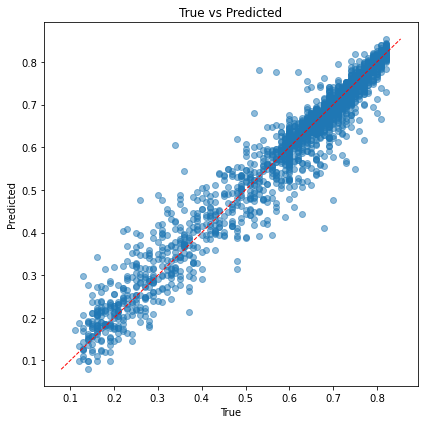


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-5.9363,0.0028,0.0407,0.2566
0.2-0.3,144,-3.1560,0.0035,0.0445,0.1825
0.3-0.4,131,-5.2035,0.0045,0.0509,0.1493
0.4-0.5,130,-2.0714,0.0032,0.0452,0.0996
0.5-0.6,180,-3.0546,0.0030,0.0381,0.0690
0.6-0.7,1009,-0.0831,0.0010,0.0199,0.0305
0.7-0.8,1014,0.0945,0.0005,0.0143,0.0193
0.8-0.9,527,-2.6735,0.0002,0.0084,0.0104



Average Segmented Metrics (skip NaN):
  R2:   -2.7605
  MSE:  0.0024
  MAE:  0.0327
  MAPE: 0.1021


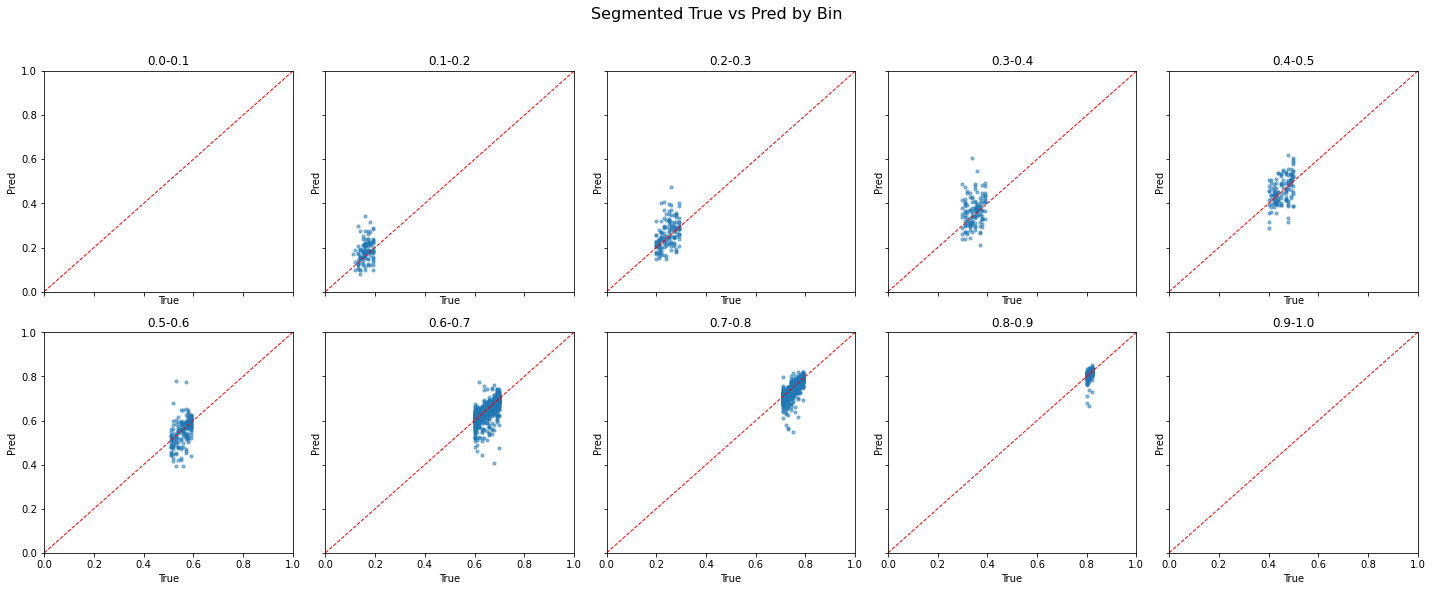


--- LSTM ---
Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 3s - loss: 0.0070 - 3s/epoch - 7ms/step
Epoch 2/200
407/407 - 1s - loss: 0.0036 - 1s/epoch - 4ms/step
Epoch 3/200
407/407 - 1s - loss: 0.0028 - 1s/epoch - 3ms/step
Epoch 4/200
407/407 - 1s - loss: 0.0025 - 1s/epoch - 4ms/step
Epoch 5/200
407/407 - 1s - loss: 0.0024 - 1s/epoch - 4ms/step
Epoch 6/200
407/407 - 1s - loss: 0.0023 - 1s/epoch - 4

Epoch 112/200
407/407 - 1s - loss: 3.5064e-04 - 1s/epoch - 4ms/step
Epoch 113/200
407/407 - 1s - loss: 3.5070e-04 - 1s/epoch - 4ms/step
Epoch 114/200
407/407 - 1s - loss: 3.4153e-04 - 1s/epoch - 4ms/step
Epoch 115/200
407/407 - 1s - loss: 3.3510e-04 - 1s/epoch - 3ms/step
Epoch 116/200
407/407 - 1s - loss: 3.3662e-04 - 1s/epoch - 3ms/step
Epoch 117/200
407/407 - 2s - loss: 3.2576e-04 - 2s/epoch - 4ms/step
Epoch 118/200
407/407 - 2s - loss: 3.3776e-04 - 2s/epoch - 5ms/step
Epoch 119/200
407/407 - 2s - loss: 3.1460e-04 - 2s/epoch - 4ms/step
Epoch 120/200
407/407 - 2s - loss: 3.0867e-04 - 2s/epoch - 4ms/step
Epoch 121/200
407/407 - 2s - loss: 3.0695e-04 - 2s/epoch - 4ms/step
Epoch 122/200
407/407 - 2s - loss: 2.9618e-04 - 2s/epoch - 4ms/step
Epoch 123/200
407/407 - 1s - loss: 3.0268e-04 - 1s/epoch - 3ms/step
Epoch 124/200
407/407 - 1s - loss: 2.9353e-04 - 1s/epoch - 4ms/step
Epoch 125/200
407/407 - 1s - loss: 2.9145e-04 - 1s/epoch - 4ms/step
Epoch 126/200
407/407 - 2s - loss: 2.9517e-04 - 

,Value
Metric,
MSE,0.0012
MAE,0.0193
MAPE,0.0458
R2,0.9590


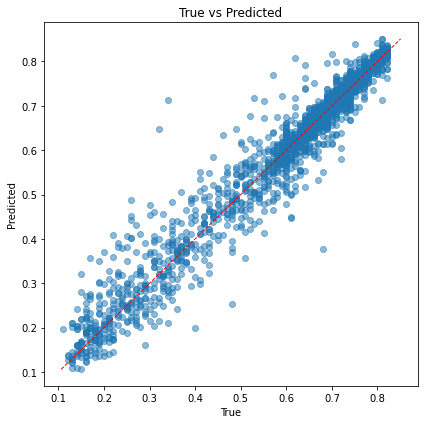


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-6.2050,0.0030,0.0394,0.2464
0.2-0.3,144,-4.4754,0.0047,0.0490,0.2025
0.3-0.4,131,-6.2607,0.0053,0.0501,0.1485
0.4-0.5,130,-2.9576,0.0041,0.0477,0.1063
0.5-0.6,180,-2.7673,0.0027,0.0375,0.0683
0.6-0.7,1009,0.1307,0.0008,0.0170,0.0261
0.7-0.8,1014,0.5163,0.0003,0.0110,0.0148
0.8-0.9,527,-0.8527,0.0001,0.0067,0.0082



Average Segmented Metrics (skip NaN):
  R2:   -2.8590
  MSE:  0.0026
  MAE:  0.0323
  MAPE: 0.1026


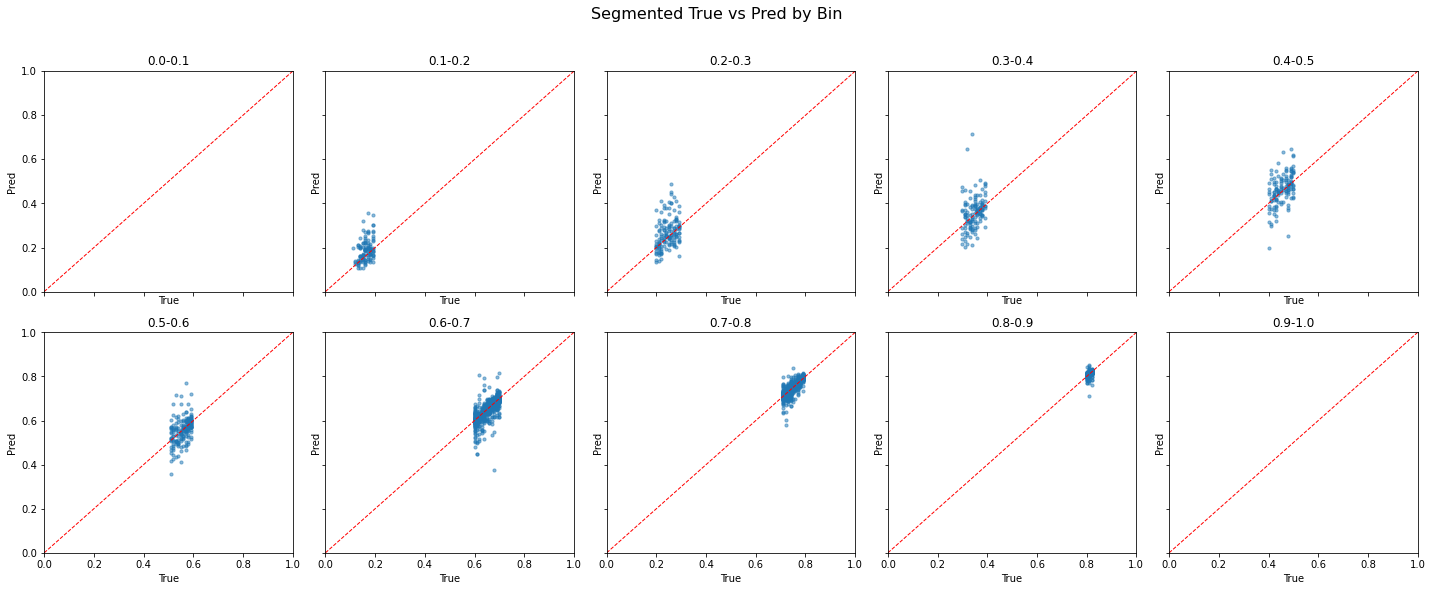

In [11]:
# 3）训练并评估 Simple RNN
# Ensure dtype
X_seq_train = X_seq_train.astype(np.float32)
X_seq_test  = X_seq_test.astype(np.float32)
y_train     = y_train.astype(np.float32)
y_test      = y_test.astype(np.float32)
print("\n--- Simple RNN ---")
model_rnn = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, 
        input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    tf.keras.layers.Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(
    X_seq_train, y_train,
    epochs=200, batch_size=32,
     verbose=2
)
y_pred_rnn = model_rnn.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_rnn)

# 4）训练并评估 LSTM
print("\n--- LSTM ---")
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, 
        input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    tf.keras.layers.Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(
    X_seq_train, y_train,
    epochs=200, batch_size=32,
     verbose=2
)
y_pred_lstm = model_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_lstm)



--- Stacked LSTM with Dropout & Normalization ---
Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 6s - loss: 0.0296 - 6s/epoch - 14ms/step
Epoch 2/200
407/407 - 3s - loss: 0.0125 - 3s/epoch - 7ms/step
Epoch 3/200
407/407 - 3s - loss: 0.0095 - 3s/epoch - 7ms/step
Epoch 4/200
407/407 - 3s - loss: 0.0077 - 3s/epoch - 7ms/step
Epoch 5/200
407/407 - 3s - loss: 0.0061 - 3s/epoch - 7ms/step
Epoch 6/200
407/

Epoch 115/200
407/407 - 3s - loss: 8.6530e-04 - 3s/epoch - 7ms/step
Epoch 116/200
407/407 - 3s - loss: 9.2317e-04 - 3s/epoch - 7ms/step
Epoch 117/200
407/407 - 3s - loss: 8.9040e-04 - 3s/epoch - 7ms/step
Epoch 118/200
407/407 - 3s - loss: 9.1613e-04 - 3s/epoch - 7ms/step
Epoch 119/200
407/407 - 3s - loss: 8.9593e-04 - 3s/epoch - 7ms/step
Epoch 120/200
407/407 - 3s - loss: 8.9046e-04 - 3s/epoch - 7ms/step
Epoch 121/200
407/407 - 3s - loss: 9.0750e-04 - 3s/epoch - 7ms/step
Epoch 122/200
407/407 - 3s - loss: 8.6124e-04 - 3s/epoch - 7ms/step
Epoch 123/200
407/407 - 3s - loss: 9.1168e-04 - 3s/epoch - 8ms/step
Epoch 124/200
407/407 - 3s - loss: 9.0303e-04 - 3s/epoch - 8ms/step
Epoch 125/200
407/407 - 3s - loss: 8.9202e-04 - 3s/epoch - 7ms/step
Epoch 126/200
407/407 - 3s - loss: 8.5595e-04 - 3s/epoch - 7ms/step
Epoch 127/200
407/407 - 3s - loss: 8.5360e-04 - 3s/epoch - 8ms/step
Epoch 128/200
407/407 - 3s - loss: 8.9320e-04 - 3s/epoch - 7ms/step
Epoch 129/200
407/407 - 3s - loss: 8.7622e-04 - 

,Value
Metric,
MSE,0.0010
MAE,0.0185
MAPE,0.0432
R2,0.9662


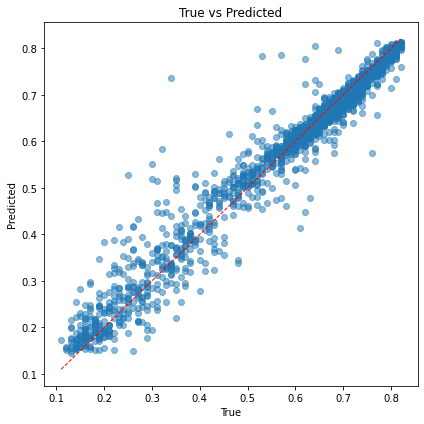


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-4.3180,0.0022,0.0360,0.2291
0.2-0.3,144,-4.0087,0.0043,0.0466,0.1916
0.3-0.4,131,-7.7321,0.0064,0.0529,0.1571
0.4-0.5,130,-1.6725,0.0028,0.0424,0.0947
0.5-0.6,180,-1.3914,0.0017,0.0257,0.0469
0.6-0.7,1009,0.5153,0.0005,0.0131,0.0200
0.7-0.8,1014,0.5055,0.0003,0.0129,0.0172
0.8-0.9,527,-2.1597,0.0002,0.0113,0.0139



Average Segmented Metrics (skip NaN):
  R2:   -2.5327
  MSE:  0.0023
  MAE:  0.0301
  MAPE: 0.0963


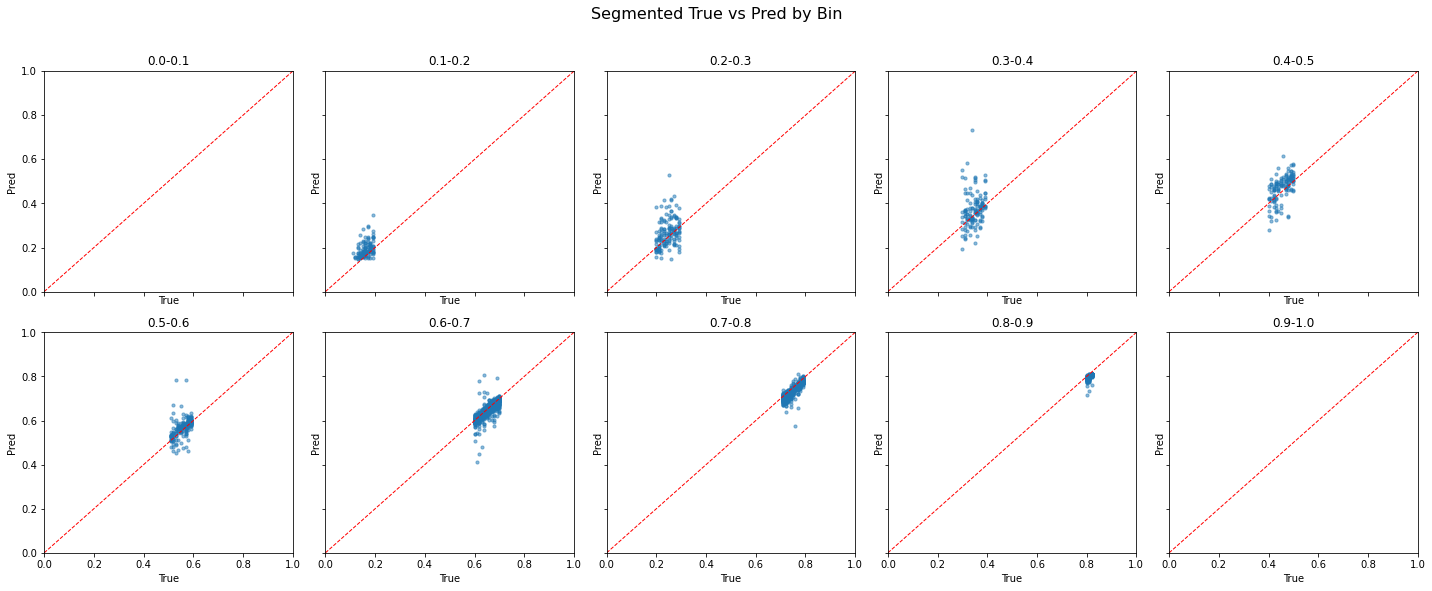

In [12]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, LayerNormalization, Dense

# 构建模型
model_stack_lstm = tf.keras.Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dropout(0.3),
    LayerNormalization(),

    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

# 编译模型
model_stack_lstm.compile(optimizer='adam', loss='mse')

# 添加 EarlyStopping（避免过拟合）
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 训练模型
print("\n--- Stacked LSTM with Dropout & Normalization ---")
model_stack_lstm.fit(
    X_seq_train, y_train,
    epochs=200, batch_size=32,
    verbose=2
)

# 预测与评估
y_pred_stack_lstm = model_stack_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stack_lstm)


Epoch 1/200
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 5s - loss: 0.0133 - 5s/epoch - 12ms/step
Epoch 2/200
407/407 - 2s - loss: 0.0037 - 2s/epoch - 5ms/step
Epoch 3/200
407/407 - 2s - loss: 0.0029 - 2s/epoch - 5ms/step
Epoch 4/200
407/407 - 2s - loss: 0.0027 - 2s/epoch - 5ms/step
Epoch 5/200
407/407 - 2s - loss: 0.0024 - 2s/epoch - 5ms/step
Epoch 6/200
407/407 - 2s - loss: 0.0022 - 2s/epoch - 4ms/step
Epoch

Epoch 112/200
407/407 - 2s - loss: 2.7868e-04 - 2s/epoch - 4ms/step
Epoch 113/200
407/407 - 2s - loss: 2.7934e-04 - 2s/epoch - 4ms/step
Epoch 114/200
407/407 - 2s - loss: 2.4226e-04 - 2s/epoch - 4ms/step
Epoch 115/200
407/407 - 2s - loss: 2.7397e-04 - 2s/epoch - 4ms/step
Epoch 116/200
407/407 - 2s - loss: 2.4771e-04 - 2s/epoch - 4ms/step
Epoch 117/200
407/407 - 2s - loss: 2.4105e-04 - 2s/epoch - 4ms/step
Epoch 118/200
407/407 - 2s - loss: 2.3295e-04 - 2s/epoch - 4ms/step
Epoch 119/200
407/407 - 2s - loss: 2.3221e-04 - 2s/epoch - 4ms/step
Epoch 120/200
407/407 - 2s - loss: 2.3440e-04 - 2s/epoch - 4ms/step
Epoch 121/200
407/407 - 2s - loss: 2.2736e-04 - 2s/epoch - 4ms/step
Epoch 122/200
407/407 - 2s - loss: 2.1759e-04 - 2s/epoch - 4ms/step
Epoch 123/200
407/407 - 2s - loss: 2.3522e-04 - 2s/epoch - 4ms/step
Epoch 124/200
407/407 - 2s - loss: 2.2399e-04 - 2s/epoch - 4ms/step
Epoch 125/200
407/407 - 2s - loss: 2.1720e-04 - 2s/epoch - 5ms/step
Epoch 126/200
407/407 - 2s - loss: 2.1720e-04 - 

,Value
Metric,
MSE,0.0011
MAE,0.0180
MAPE,0.0425
R2,0.9625


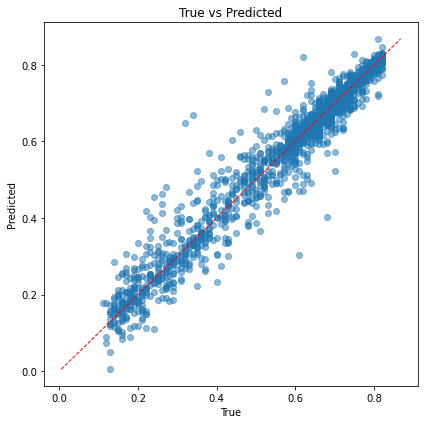


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-4.3478,0.0022,0.0353,0.2237
0.2-0.3,144,-4.0012,0.0043,0.0457,0.1906
0.3-0.4,131,-5.4674,0.0047,0.0448,0.1308
0.4-0.5,130,-2.7464,0.0039,0.0485,0.1080
0.5-0.6,180,-2.2599,0.0024,0.0342,0.0623
0.6-0.7,1009,0.1062,0.0009,0.0168,0.0259
0.7-0.8,1014,0.5842,0.0002,0.0099,0.0133
0.8-0.9,527,-0.5951,0.0001,0.0045,0.0056



Average Segmented Metrics (skip NaN):
  R2:   -2.3409
  MSE:  0.0023
  MAE:  0.0300
  MAPE: 0.0950


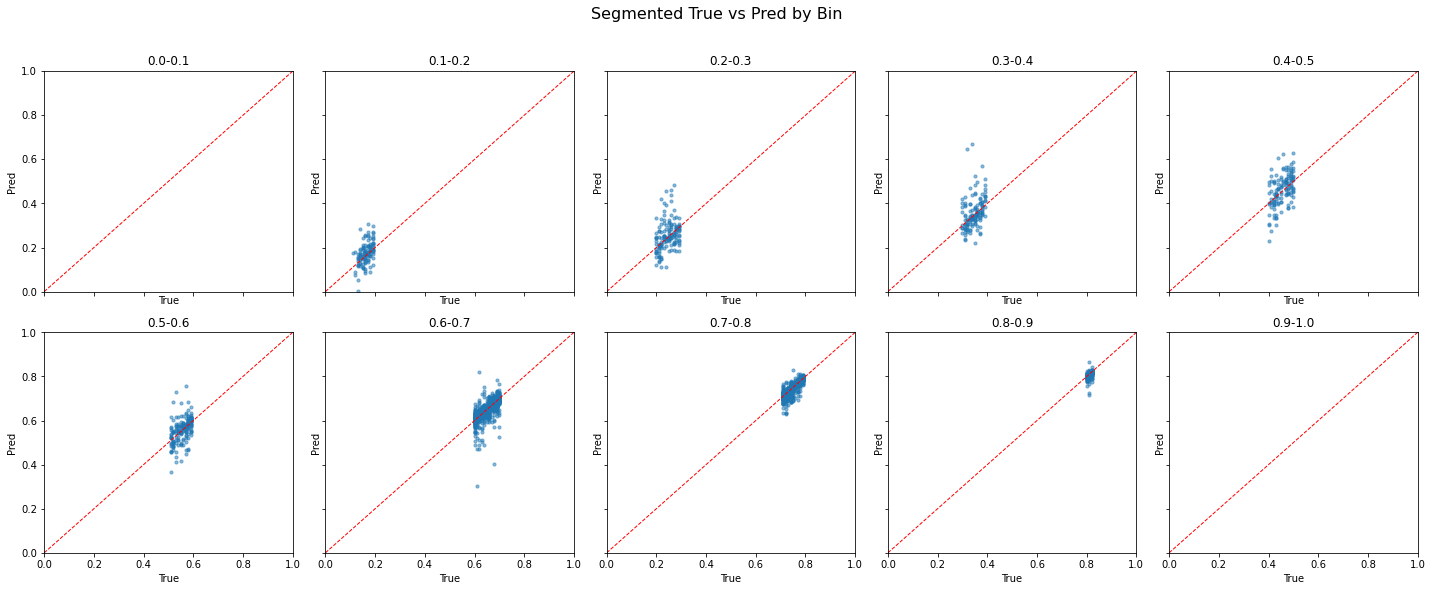

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

# 构建 Bidirectional LSTM 模型
model_bilstm = Sequential([
    Bidirectional(LSTM(64), input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dense(1)
])

# 编译
model_bilstm.compile(optimizer='adam', loss='mse')

# 训练
model_bilstm.fit(
    X_seq_train, y_train,
    epochs=200, batch_size=32,
    verbose=2  # 关闭 validation_split
)

# 预测 & 评估
y_pred_bilstm = model_bilstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_bilstm)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-07-02 15:02:32.052916: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:690] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" vendor: "GenuineIntel" model: "110" frequency: 2300 num_cores: 8 environment { key: "cpu_instruction_set" value: "SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 524288 l3_cache_size: 8388608 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


407/407 - 4s - loss: 0.0149 - 4s/epoch - 10ms/step
Epoch 2/300
407/407 - 2s - loss: 0.0055 - 2s/epoch - 5ms/step
Epoch 3/300
407/407 - 2s - loss: 0.0039 - 2s/epoch - 4ms/step
Epoch 4/300
407/407 - 2s - loss: 0.0031 - 2s/epoch - 4ms/step
Epoch 5/300
407/407 - 2s - loss: 0.0028 - 2s/epoch - 4ms/step
Epoch 6/300
407/407 - 2s - loss: 0.0028 - 2s/epoch - 4ms/step
Epoch 7/300
407/407 - 2s - loss: 0.0026 - 2s/epoch - 4ms/step
Epoch 8/300
407/407 - 2s - loss: 0.0024 - 2s/epoch - 4ms/step
Epoch 9/300
407/407 - 2s - loss: 0.0023 - 2s/epoch - 4ms/step
Epoch 10/300
407/407 - 2s - loss: 0.0022 - 2s/epoch - 4ms/step
Epoch 11/300
407/407 - 2s - loss: 0.0020 - 2s/epoch - 4ms/step
Epoch 12/300
407/407 - 2s - loss: 0.0019 - 2s/epoch - 4ms/step
Epoch 13/300
407/407 - 2s - loss: 0.0020 - 2s/epoch - 4ms/step
Epoch 14/300
407/407 - 2s - loss: 0.0019 - 2s/epoch - 4ms/step
Epoch 15/300
407/407 - 2s - loss: 0.0018 - 2s/epoch - 4ms/step
Epoch 16/300
407/407 - 2s - loss: 0.0017 - 2s/epoch - 4ms/step
Epoch 17/300

407/407 - 2s - loss: 3.9100e-04 - 2s/epoch - 4ms/step
Epoch 127/300
407/407 - 2s - loss: 3.8772e-04 - 2s/epoch - 4ms/step
Epoch 128/300
407/407 - 2s - loss: 3.7507e-04 - 2s/epoch - 4ms/step
Epoch 129/300
407/407 - 2s - loss: 3.6544e-04 - 2s/epoch - 4ms/step
Epoch 130/300
407/407 - 2s - loss: 3.6052e-04 - 2s/epoch - 4ms/step
Epoch 131/300
407/407 - 2s - loss: 3.7396e-04 - 2s/epoch - 4ms/step
Epoch 132/300
407/407 - 2s - loss: 3.6028e-04 - 2s/epoch - 4ms/step
Epoch 133/300
407/407 - 2s - loss: 3.5256e-04 - 2s/epoch - 4ms/step
Epoch 134/300
407/407 - 2s - loss: 3.5202e-04 - 2s/epoch - 4ms/step
Epoch 135/300
407/407 - 2s - loss: 3.7136e-04 - 2s/epoch - 4ms/step
Epoch 136/300
407/407 - 2s - loss: 3.6138e-04 - 2s/epoch - 4ms/step
Epoch 137/300
407/407 - 2s - loss: 3.3153e-04 - 2s/epoch - 4ms/step
Epoch 138/300
407/407 - 2s - loss: 3.2441e-04 - 2s/epoch - 4ms/step
Epoch 139/300
407/407 - 2s - loss: 3.4517e-04 - 2s/epoch - 4ms/step
Epoch 140/300
407/407 - 2s - loss: 3.2216e-04 - 2s/epoch - 4ms

Epoch 247/300
407/407 - 2s - loss: 1.1504e-04 - 2s/epoch - 4ms/step
Epoch 248/300
407/407 - 2s - loss: 1.2397e-04 - 2s/epoch - 4ms/step
Epoch 249/300
407/407 - 2s - loss: 1.1762e-04 - 2s/epoch - 4ms/step
Epoch 250/300
407/407 - 2s - loss: 1.1357e-04 - 2s/epoch - 4ms/step
Epoch 251/300
407/407 - 2s - loss: 1.3064e-04 - 2s/epoch - 4ms/step
Epoch 252/300
407/407 - 2s - loss: 1.2651e-04 - 2s/epoch - 4ms/step
Epoch 253/300
407/407 - 2s - loss: 1.1954e-04 - 2s/epoch - 4ms/step
Epoch 254/300
407/407 - 2s - loss: 1.1787e-04 - 2s/epoch - 4ms/step
Epoch 255/300
407/407 - 2s - loss: 1.1162e-04 - 2s/epoch - 4ms/step
Epoch 256/300
407/407 - 2s - loss: 1.1335e-04 - 2s/epoch - 4ms/step
Epoch 257/300
407/407 - 2s - loss: 1.1080e-04 - 2s/epoch - 4ms/step
Epoch 258/300
407/407 - 2s - loss: 1.2294e-04 - 2s/epoch - 5ms/step
Epoch 259/300
407/407 - 2s - loss: 1.1230e-04 - 2s/epoch - 4ms/step
Epoch 260/300
407/407 - 2s - loss: 1.1683e-04 - 2s/epoch - 4ms/step
Epoch 261/300
407/407 - 2s - loss: 1.1604e-04 - 

2025-07-02 15:10:45.087534: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:690] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" vendor: "GenuineIntel" model: "110" frequency: 2300 num_cores: 8 environment { key: "cpu_instruction_set" value: "SSE, SSE2, SSE3, SSSE3, SSE4.1, SSE4.2" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 49152 l2_cache_size: 524288 l3_cache_size: 8388608 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


102/102 [==============================] - 1s 2ms/step
Overall Metrics:


,Value
Metric,
MSE,0.0012
MAE,0.0206
MAPE,0.0460
R2,0.9584


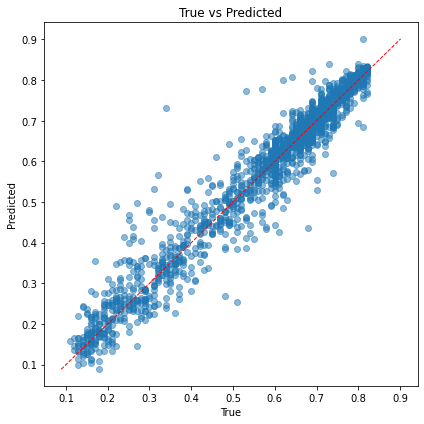


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-3.5964,0.0019,0.0318,0.1991
0.2-0.3,144,-4.6250,0.0048,0.0493,0.2031
0.3-0.4,131,-6.2026,0.0053,0.0479,0.1412
0.4-0.5,130,-1.8774,0.0030,0.0413,0.0922
0.5-0.6,180,-3.6511,0.0034,0.0399,0.0727
0.6-0.7,1009,0.0483,0.0009,0.0195,0.0299
0.7-0.8,1014,0.3930,0.0004,0.0132,0.0177
0.8-0.9,527,-2.0624,0.0002,0.0085,0.0105



Average Segmented Metrics (skip NaN):
  R2:   -2.6967
  MSE:  0.0025
  MAE:  0.0314
  MAPE: 0.0958


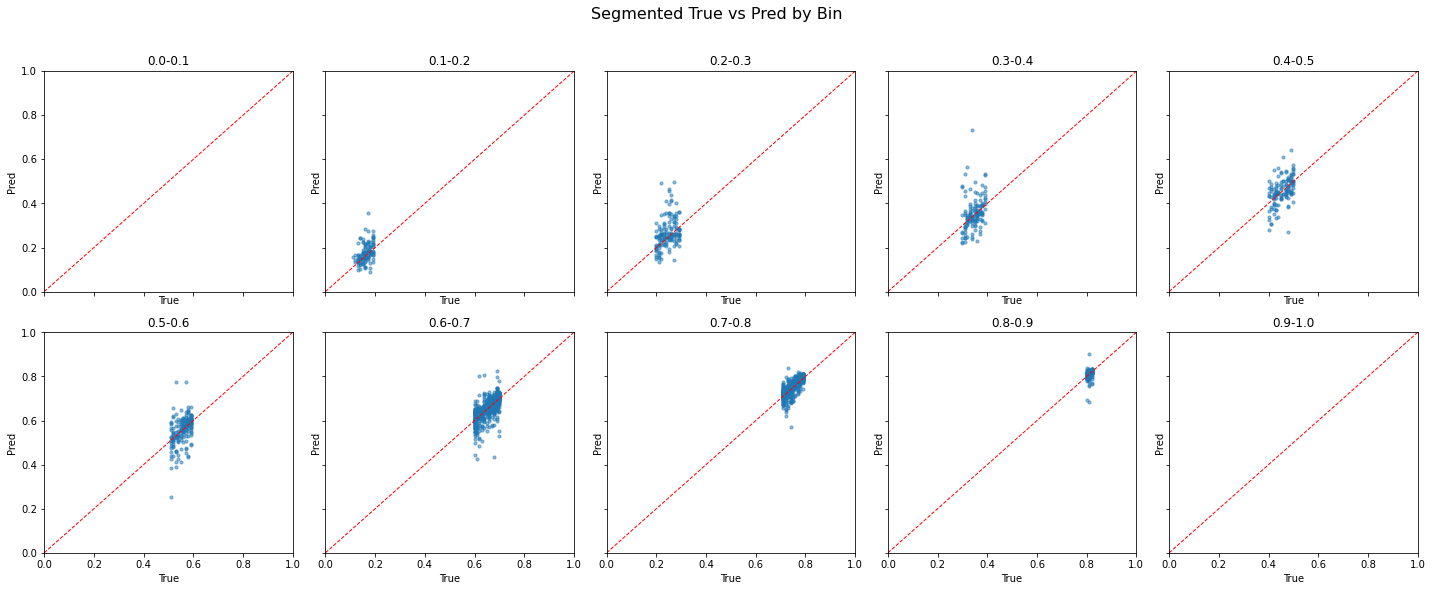

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate, RepeatVector

# LSTM + Attention 自定义模型
input_seq = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]))
lstm_out = LSTM(64, return_sequences=True)(input_seq)

# 注意力机制
attention = Attention()([lstm_out, lstm_out])
context = tf.reduce_mean(attention, axis=1)  # 聚合注意力上下文

# 输出层
output = Dense(1)(context)

# 构建模型
model_lstm_att = Model(inputs=input_seq, outputs=output)

# 编译模型
model_lstm_att.compile(optimizer='adam', loss='mse')

# 训练模型
model_lstm_att.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# 预测并评估
y_pred_att = model_lstm_att.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_att)


Epoch 1/600
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 6s - loss: 0.0129 - 6s/epoch - 14ms/step
Epoch 2/600
407/407 - 3s - loss: 0.0044 - 3s/epoch - 6ms/step
Epoch 3/600
407/407 - 3s - loss: 0.0030 - 3s/epoch - 6ms/step
Epoch 4/600
407/407 - 3s - loss: 0.0026 - 3s/epoch - 6ms/step
Epoch 5/600
407/407 - 2s - loss: 0.0023 - 2s/epoch - 6ms/step
Epoch 6/600
407/407 - 3s - loss: 0.0021 - 3s/epoch - 6ms/step
Epoch

Epoch 112/600
407/407 - 3s - loss: 1.9050e-04 - 3s/epoch - 6ms/step
Epoch 113/600
407/407 - 3s - loss: 1.8205e-04 - 3s/epoch - 7ms/step
Epoch 114/600
407/407 - 2s - loss: 1.8540e-04 - 2s/epoch - 6ms/step
Epoch 115/600
407/407 - 3s - loss: 1.8173e-04 - 3s/epoch - 6ms/step
Epoch 116/600
407/407 - 3s - loss: 1.7257e-04 - 3s/epoch - 6ms/step
Epoch 117/600
407/407 - 2s - loss: 1.6664e-04 - 2s/epoch - 6ms/step
Epoch 118/600
407/407 - 3s - loss: 1.7627e-04 - 3s/epoch - 6ms/step
Epoch 119/600
407/407 - 2s - loss: 1.7205e-04 - 2s/epoch - 6ms/step
Epoch 120/600
407/407 - 2s - loss: 1.6402e-04 - 2s/epoch - 6ms/step
Epoch 121/600
407/407 - 3s - loss: 1.5398e-04 - 3s/epoch - 6ms/step
Epoch 122/600
407/407 - 3s - loss: 1.6471e-04 - 3s/epoch - 6ms/step
Epoch 123/600
407/407 - 2s - loss: 1.5485e-04 - 2s/epoch - 6ms/step
Epoch 124/600
407/407 - 3s - loss: 1.6674e-04 - 3s/epoch - 6ms/step
Epoch 125/600
407/407 - 2s - loss: 1.5538e-04 - 2s/epoch - 6ms/step
Epoch 126/600
407/407 - 3s - loss: 1.5572e-04 - 

Epoch 233/600
407/407 - 3s - loss: 6.7123e-05 - 3s/epoch - 7ms/step
Epoch 234/600
407/407 - 4s - loss: 6.8090e-05 - 4s/epoch - 9ms/step
Epoch 235/600
407/407 - 3s - loss: 5.4436e-05 - 3s/epoch - 6ms/step
Epoch 236/600
407/407 - 3s - loss: 5.1931e-05 - 3s/epoch - 6ms/step
Epoch 237/600
407/407 - 2s - loss: 5.1398e-05 - 2s/epoch - 6ms/step
Epoch 238/600
407/407 - 3s - loss: 6.3318e-05 - 3s/epoch - 6ms/step
Epoch 239/600
407/407 - 2s - loss: 5.8982e-05 - 2s/epoch - 6ms/step
Epoch 240/600
407/407 - 3s - loss: 6.1732e-05 - 3s/epoch - 6ms/step
Epoch 241/600
407/407 - 2s - loss: 5.5612e-05 - 2s/epoch - 6ms/step
Epoch 242/600
407/407 - 3s - loss: 5.1595e-05 - 3s/epoch - 7ms/step
Epoch 243/600
407/407 - 3s - loss: 6.1794e-05 - 3s/epoch - 7ms/step
Epoch 244/600
407/407 - 2s - loss: 6.0991e-05 - 2s/epoch - 6ms/step
Epoch 245/600
407/407 - 2s - loss: 5.7692e-05 - 2s/epoch - 6ms/step
Epoch 246/600
407/407 - 3s - loss: 5.2545e-05 - 3s/epoch - 6ms/step
Epoch 247/600
407/407 - 3s - loss: 5.4058e-05 - 

Epoch 354/600
407/407 - 3s - loss: 3.6188e-05 - 3s/epoch - 7ms/step
Epoch 355/600
407/407 - 3s - loss: 3.7101e-05 - 3s/epoch - 8ms/step
Epoch 356/600
407/407 - 3s - loss: 3.8833e-05 - 3s/epoch - 7ms/step
Epoch 357/600
407/407 - 3s - loss: 3.8937e-05 - 3s/epoch - 7ms/step
Epoch 358/600
407/407 - 3s - loss: 3.8804e-05 - 3s/epoch - 7ms/step
Epoch 359/600
407/407 - 3s - loss: 3.5192e-05 - 3s/epoch - 6ms/step
Epoch 360/600
407/407 - 3s - loss: 3.6399e-05 - 3s/epoch - 7ms/step
Epoch 361/600
407/407 - 3s - loss: 3.8329e-05 - 3s/epoch - 7ms/step
Epoch 362/600
407/407 - 3s - loss: 3.8239e-05 - 3s/epoch - 7ms/step
Epoch 363/600
407/407 - 3s - loss: 3.8355e-05 - 3s/epoch - 7ms/step
Epoch 364/600
407/407 - 3s - loss: 3.9049e-05 - 3s/epoch - 6ms/step
Epoch 365/600
407/407 - 3s - loss: 3.6625e-05 - 3s/epoch - 7ms/step
Epoch 366/600
407/407 - 3s - loss: 3.4149e-05 - 3s/epoch - 6ms/step
Epoch 367/600
407/407 - 3s - loss: 3.1679e-05 - 3s/epoch - 7ms/step
Epoch 368/600
407/407 - 3s - loss: 3.6328e-05 - 

Epoch 475/600
407/407 - 3s - loss: 2.7013e-05 - 3s/epoch - 6ms/step
Epoch 476/600
407/407 - 3s - loss: 2.8443e-05 - 3s/epoch - 7ms/step
Epoch 477/600
407/407 - 3s - loss: 2.8051e-05 - 3s/epoch - 7ms/step
Epoch 478/600
407/407 - 3s - loss: 2.8143e-05 - 3s/epoch - 6ms/step
Epoch 479/600
407/407 - 3s - loss: 2.6896e-05 - 3s/epoch - 6ms/step
Epoch 480/600
407/407 - 3s - loss: 2.7712e-05 - 3s/epoch - 6ms/step
Epoch 481/600
407/407 - 3s - loss: 2.7296e-05 - 3s/epoch - 7ms/step
Epoch 482/600
407/407 - 3s - loss: 2.9070e-05 - 3s/epoch - 7ms/step
Epoch 483/600
407/407 - 3s - loss: 2.6254e-05 - 3s/epoch - 6ms/step
Epoch 484/600
407/407 - 3s - loss: 2.5756e-05 - 3s/epoch - 7ms/step
Epoch 485/600
407/407 - 2s - loss: 2.6064e-05 - 2s/epoch - 6ms/step
Epoch 486/600
407/407 - 2s - loss: 2.8415e-05 - 2s/epoch - 6ms/step
Epoch 487/600
407/407 - 2s - loss: 3.0883e-05 - 2s/epoch - 6ms/step
Epoch 488/600
407/407 - 3s - loss: 2.7590e-05 - 3s/epoch - 6ms/step
Epoch 489/600
407/407 - 3s - loss: 2.9490e-05 - 

Epoch 596/600
407/407 - 3s - loss: 2.1821e-05 - 3s/epoch - 7ms/step
Epoch 597/600
407/407 - 3s - loss: 2.2964e-05 - 3s/epoch - 7ms/step
Epoch 598/600
407/407 - 3s - loss: 2.2931e-05 - 3s/epoch - 7ms/step
Epoch 599/600
407/407 - 3s - loss: 2.4293e-05 - 3s/epoch - 7ms/step
Epoch 600/600
407/407 - 3s - loss: 2.3613e-05 - 3s/epoch - 7ms/step
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
102/102 [=============================

,Value
Metric,
MSE,0.0010
MAE,0.0165
MAPE,0.0399
R2,0.9673


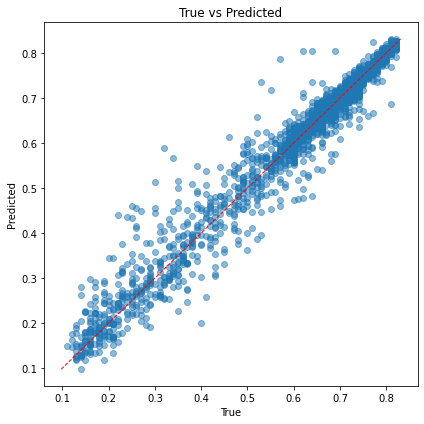


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-4.0755,0.0021,0.0335,0.2102
0.2-0.3,144,-3.7703,0.0041,0.0435,0.1803
0.3-0.4,131,-5.3254,0.0046,0.0492,0.1446
0.4-0.5,130,-2.4947,0.0036,0.0465,0.1031
0.5-0.6,180,-2.0206,0.0022,0.0318,0.0580
0.6-0.7,1009,0.3933,0.0006,0.0144,0.0222
0.7-0.8,1014,0.6550,0.0002,0.0090,0.0121
0.8-0.9,527,-0.0324,0.0001,0.0032,0.0040



Average Segmented Metrics (skip NaN):
  R2:   -2.0838
  MSE:  0.0022
  MAE:  0.0289
  MAPE: 0.0918


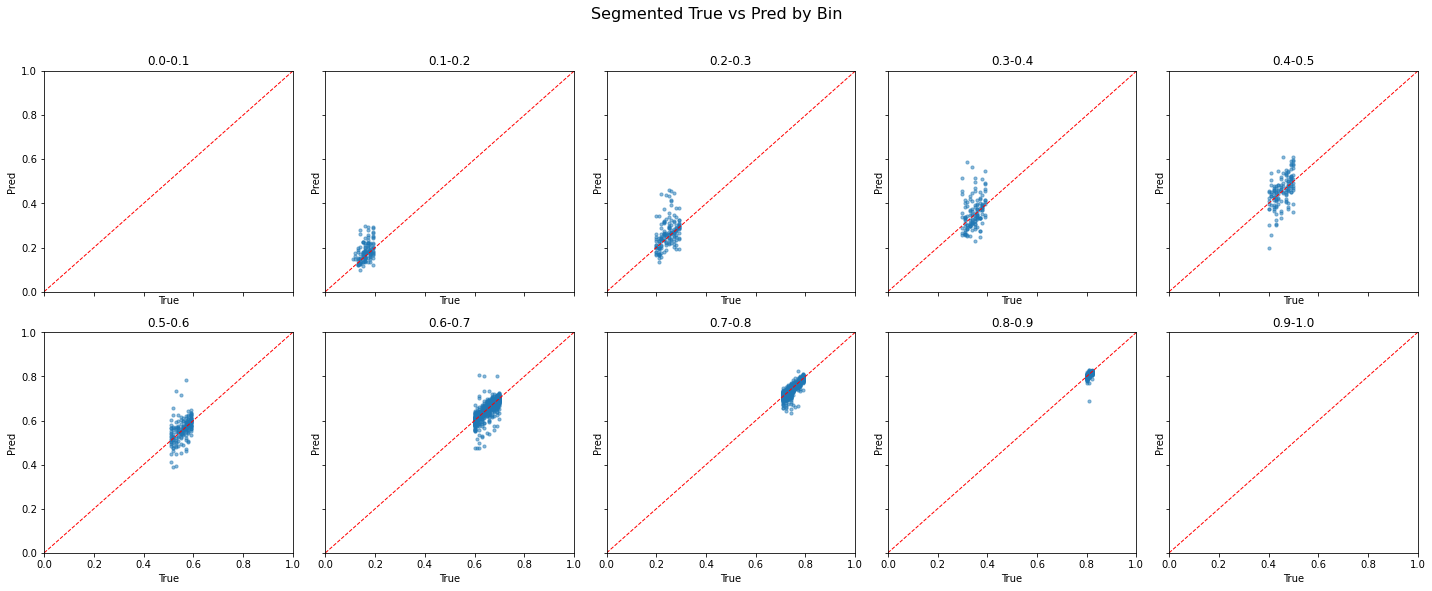

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 构建 Stacked LSTM 模型
model_stacked_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),  # 第二层 LSTM
    Dense(1)   # 输出层
])

model_stacked_lstm.compile(optimizer='adam', loss='mse')

# 训练
model_stacked_lstm.fit(
    X_seq_train, y_train,
    epochs=600, batch_size=32,
    verbose=2
)

# 预测 + 评估
y_pred_stacked = model_stacked_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stacked)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 5s - loss: 0.0132 - 5s/epoch - 13ms/step
Epoch 2/300
407/407 - 2s - loss: 0.0040 - 2s/epoch - 5ms/step
Epoch 3/300
407/407 - 2s - loss: 0.0029 - 2s/epoch - 5ms/step
Epoch 4/300
407/407 - 2s - loss: 0.0025 - 2s/epoch - 5ms/step
Epoch 5/300
407/407 - 2s - loss: 0.0023 - 2s/epoch - 5ms/step
Epoch 6/300
407/407 - 2s - loss: 0.0022 - 2s/epoch - 5ms/step
Epoch

Epoch 112/300
407/407 - 2s - loss: 2.8392e-04 - 2s/epoch - 5ms/step
Epoch 113/300
407/407 - 2s - loss: 2.8451e-04 - 2s/epoch - 5ms/step
Epoch 114/300
407/407 - 2s - loss: 2.6826e-04 - 2s/epoch - 4ms/step
Epoch 115/300
407/407 - 2s - loss: 2.7841e-04 - 2s/epoch - 4ms/step
Epoch 116/300
407/407 - 2s - loss: 2.7669e-04 - 2s/epoch - 4ms/step
Epoch 117/300
407/407 - 2s - loss: 2.6718e-04 - 2s/epoch - 4ms/step
Epoch 118/300
407/407 - 2s - loss: 2.9003e-04 - 2s/epoch - 4ms/step
Epoch 119/300
407/407 - 2s - loss: 2.5962e-04 - 2s/epoch - 5ms/step
Epoch 120/300
407/407 - 2s - loss: 2.4193e-04 - 2s/epoch - 4ms/step
Epoch 121/300
407/407 - 2s - loss: 2.3608e-04 - 2s/epoch - 5ms/step
Epoch 122/300
407/407 - 2s - loss: 2.4869e-04 - 2s/epoch - 4ms/step
Epoch 123/300
407/407 - 2s - loss: 2.3582e-04 - 2s/epoch - 4ms/step
Epoch 124/300
407/407 - 2s - loss: 2.4248e-04 - 2s/epoch - 4ms/step
Epoch 125/300
407/407 - 2s - loss: 2.2759e-04 - 2s/epoch - 4ms/step
Epoch 126/300
407/407 - 2s - loss: 2.2628e-04 - 

Epoch 233/300
407/407 - 2s - loss: 9.4491e-05 - 2s/epoch - 5ms/step
Epoch 234/300
407/407 - 2s - loss: 7.5785e-05 - 2s/epoch - 5ms/step
Epoch 235/300
407/407 - 2s - loss: 7.6007e-05 - 2s/epoch - 5ms/step
Epoch 236/300
407/407 - 2s - loss: 8.1147e-05 - 2s/epoch - 5ms/step
Epoch 237/300
407/407 - 2s - loss: 8.6455e-05 - 2s/epoch - 6ms/step
Epoch 238/300
407/407 - 2s - loss: 1.0235e-04 - 2s/epoch - 5ms/step
Epoch 239/300
407/407 - 2s - loss: 7.3298e-05 - 2s/epoch - 6ms/step
Epoch 240/300
407/407 - 2s - loss: 7.0882e-05 - 2s/epoch - 5ms/step
Epoch 241/300
407/407 - 2s - loss: 7.4361e-05 - 2s/epoch - 6ms/step
Epoch 242/300
407/407 - 2s - loss: 7.1931e-05 - 2s/epoch - 5ms/step
Epoch 243/300
407/407 - 2s - loss: 7.6961e-05 - 2s/epoch - 5ms/step
Epoch 244/300
407/407 - 2s - loss: 7.8831e-05 - 2s/epoch - 5ms/step
Epoch 245/300
407/407 - 2s - loss: 7.9165e-05 - 2s/epoch - 5ms/step
Epoch 246/300
407/407 - 2s - loss: 7.6231e-05 - 2s/epoch - 5ms/step
Epoch 247/300
407/407 - 2s - loss: 7.6514e-05 - 

,Value
Metric,
MSE,0.0012
MAE,0.0189
MAPE,0.0447
R2,0.9597


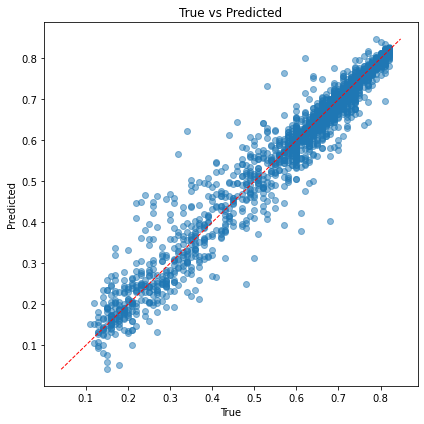


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-4.7793,0.0024,0.0345,0.2190
0.2-0.3,144,-4.6751,0.0048,0.0494,0.2031
0.3-0.4,131,-5.9085,0.0051,0.0521,0.1525
0.4-0.5,130,-3.2362,0.0044,0.0512,0.1138
0.5-0.6,180,-2.4721,0.0025,0.0352,0.0642
0.6-0.7,1009,0.1166,0.0008,0.0174,0.0268
0.7-0.8,1014,0.5009,0.0003,0.0105,0.0142
0.8-0.9,527,-0.4123,0.0001,0.0045,0.0056



Average Segmented Metrics (skip NaN):
  R2:   -2.6083
  MSE:  0.0025
  MAE:  0.0319
  MAPE: 0.0999


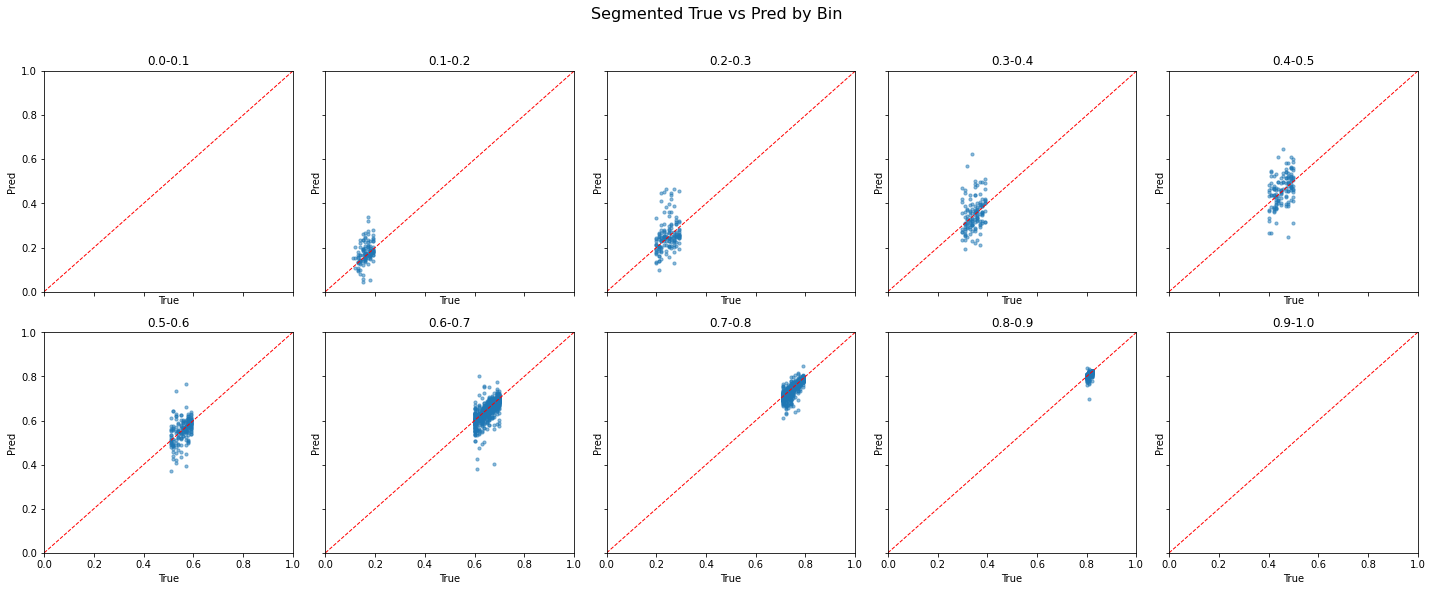

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional

# 构建 Bidirectional LSTM 模型
model_bi_lstm = Sequential([
    Bidirectional(LSTM(64), input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dense(1)
])

model_bi_lstm.compile(optimizer='adam', loss='mse')

# 训练
model_bi_lstm.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# 预测 + 评估
y_pred_bilstm = model_bi_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_bilstm)



--- 3-Layer Stacked LSTM ---
Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
407/407 - 14s - loss: 0.0168 - 14s/epoch - 35ms/step
Epoch 2/300
407/407 - 7s - loss: 0.0062 - 7s/epoch - 17ms/step
Epoch 3/300
407/407 - 7s - loss: 0.0042 - 7s/epoch - 17ms/step
Epoch 4/300
407/407 - 7s - loss: 0.0035 - 7s/epoch - 16ms/step
Epoch 5/300
407/407 - 7s - loss: 0.0031 - 7s/epoch - 17ms/step
Epoch 6/300
407/407 - 7s - loss

Epoch 110/300
407/407 - 6s - loss: 3.2140e-04 - 6s/epoch - 14ms/step
Epoch 111/300
407/407 - 6s - loss: 3.0590e-04 - 6s/epoch - 14ms/step
Epoch 112/300
407/407 - 6s - loss: 3.2116e-04 - 6s/epoch - 15ms/step
Epoch 113/300
407/407 - 8s - loss: 3.2189e-04 - 8s/epoch - 19ms/step
Epoch 114/300
407/407 - 7s - loss: 3.1118e-04 - 7s/epoch - 17ms/step
Epoch 115/300
407/407 - 5s - loss: 3.1686e-04 - 5s/epoch - 14ms/step
Epoch 116/300
407/407 - 5s - loss: 2.8826e-04 - 5s/epoch - 13ms/step
Epoch 117/300
407/407 - 6s - loss: 2.9223e-04 - 6s/epoch - 14ms/step
Epoch 118/300
407/407 - 7s - loss: 2.9222e-04 - 7s/epoch - 16ms/step
Epoch 119/300
407/407 - 8s - loss: 2.8194e-04 - 8s/epoch - 20ms/step
Epoch 120/300
407/407 - 7s - loss: 3.0386e-04 - 7s/epoch - 17ms/step
Epoch 121/300
407/407 - 7s - loss: 2.8983e-04 - 7s/epoch - 18ms/step
Epoch 122/300
407/407 - 6s - loss: 2.7610e-04 - 6s/epoch - 14ms/step
Epoch 123/300
407/407 - 6s - loss: 2.6722e-04 - 6s/epoch - 15ms/step
Epoch 124/300
407/407 - 7s - loss:

Epoch 229/300
407/407 - 7s - loss: 1.4068e-04 - 7s/epoch - 18ms/step
Epoch 230/300
407/407 - 7s - loss: 1.3862e-04 - 7s/epoch - 17ms/step
Epoch 231/300
407/407 - 7s - loss: 1.4791e-04 - 7s/epoch - 18ms/step
Epoch 232/300
407/407 - 8s - loss: 1.4599e-04 - 8s/epoch - 20ms/step
Epoch 233/300
407/407 - 9s - loss: 1.4286e-04 - 9s/epoch - 23ms/step
Epoch 234/300
407/407 - 7s - loss: 1.4349e-04 - 7s/epoch - 16ms/step
Epoch 235/300
407/407 - 7s - loss: 1.3214e-04 - 7s/epoch - 17ms/step
Epoch 236/300
407/407 - 7s - loss: 1.4060e-04 - 7s/epoch - 17ms/step
Epoch 237/300
407/407 - 7s - loss: 1.3936e-04 - 7s/epoch - 18ms/step
Epoch 238/300
407/407 - 8s - loss: 1.3589e-04 - 8s/epoch - 19ms/step
Epoch 239/300
407/407 - 6s - loss: 1.2916e-04 - 6s/epoch - 16ms/step
Epoch 240/300
407/407 - 6s - loss: 1.3774e-04 - 6s/epoch - 16ms/step
Epoch 241/300
407/407 - 7s - loss: 1.6010e-04 - 7s/epoch - 18ms/step
Epoch 242/300
407/407 - 7s - loss: 1.2942e-04 - 7s/epoch - 16ms/step
Epoch 243/300
407/407 - 7s - loss:

,Value
Metric,
MSE,0.0009
MAE,0.0157
MAPE,0.0382
R2,0.9687


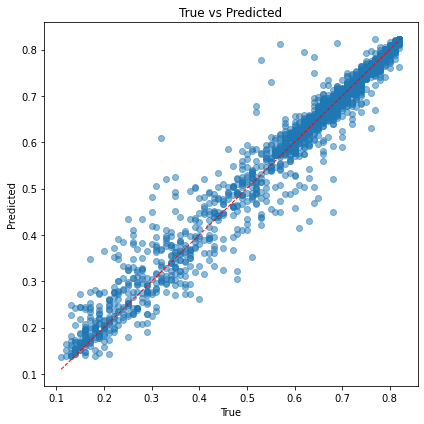


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-4.0242,0.0021,0.0325,0.2058
0.2-0.3,144,-3.0762,0.0035,0.0425,0.1742
0.3-0.4,131,-4.8534,0.0043,0.0462,0.1363
0.4-0.5,130,-1.7733,0.0029,0.0412,0.0912
0.5-0.6,180,-2.5254,0.0026,0.0335,0.0609
0.6-0.7,1009,0.3126,0.0007,0.0137,0.0210
0.7-0.8,1014,0.7072,0.0002,0.0083,0.0111
0.8-0.9,527,0.4099,0.0000,0.0030,0.0037



Average Segmented Metrics (skip NaN):
  R2:   -1.8528
  MSE:  0.0020
  MAE:  0.0276
  MAPE: 0.0880


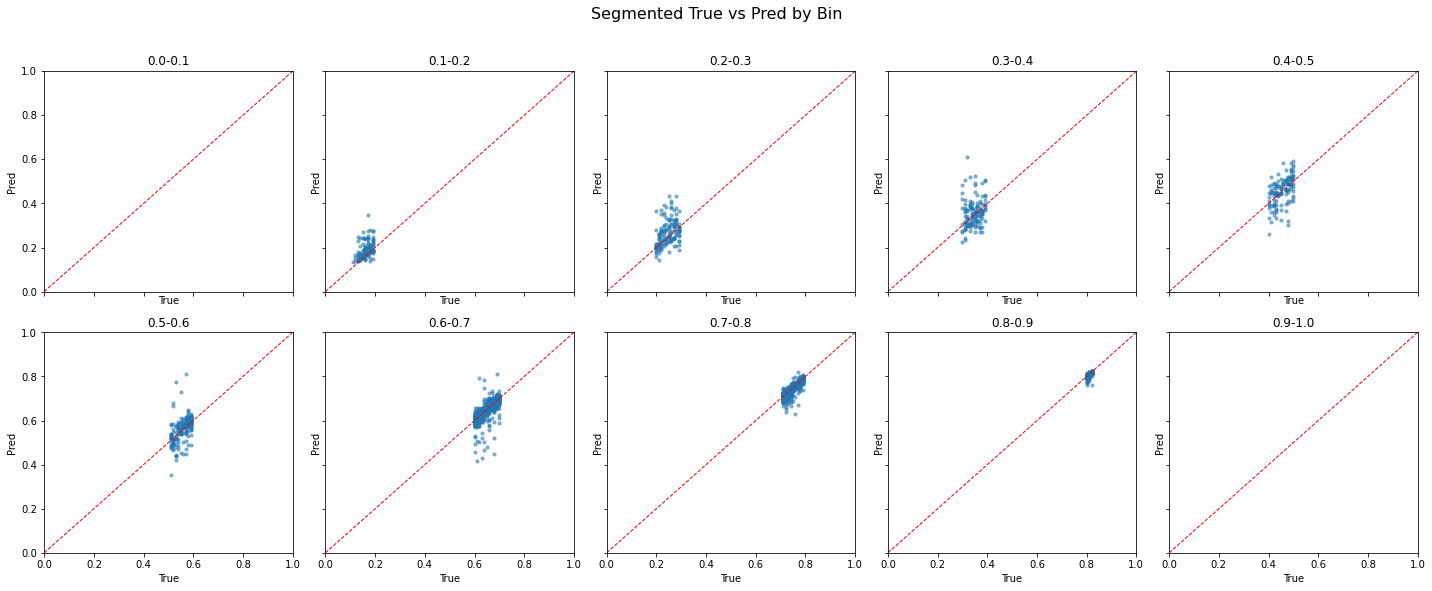

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_deep_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model_deep_lstm.compile(optimizer='adam', loss='mse')

print("\n--- 3-Layer Stacked LSTM ---")
model_deep_lstm.fit(
    X_seq_train, y_train,
    epochs=300,
    batch_size=32,
    verbose=2
)

y_pred_deep_lstm = model_deep_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_deep_lstm)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing 

Epoch 98/300
407/407 - 3s - loss: 1.2864e-04 - 3s/epoch - 8ms/step
Epoch 99/300
407/407 - 3s - loss: 1.4264e-04 - 3s/epoch - 7ms/step
Epoch 100/300
407/407 - 3s - loss: 1.2145e-04 - 3s/epoch - 8ms/step
Epoch 101/300
407/407 - 4s - loss: 1.2481e-04 - 4s/epoch - 9ms/step
Epoch 102/300
407/407 - 3s - loss: 1.2254e-04 - 3s/epoch - 7ms/step
Epoch 103/300
407/407 - 3s - loss: 1.2577e-04 - 3s/epoch - 7ms/step
Epoch 104/300
407/407 - 3s - loss: 1.2327e-04 - 3s/epoch - 7ms/step
Epoch 105/300
407/407 - 4s - loss: 1.1644e-04 - 4s/epoch - 9ms/step
Epoch 106/300
407/407 - 3s - loss: 1.1888e-04 - 3s/epoch - 8ms/step
Epoch 107/300
407/407 - 3s - loss: 1.1204e-04 - 3s/epoch - 8ms/step
Epoch 108/300
407/407 - 3s - loss: 1.1143e-04 - 3s/epoch - 7ms/step
Epoch 109/300
407/407 - 3s - loss: 1.1210e-04 - 3s/epoch - 8ms/step
Epoch 110/300
407/407 - 3s - loss: 1.0505e-04 - 3s/epoch - 8ms/step
Epoch 111/300
407/407 - 3s - loss: 1.0345e-04 - 3s/epoch - 8ms/step
Epoch 112/300
407/407 - 3s - loss: 1.0628e-04 - 3s

Epoch 219/300
407/407 - 3s - loss: 3.9195e-05 - 3s/epoch - 7ms/step
Epoch 220/300
407/407 - 3s - loss: 3.9856e-05 - 3s/epoch - 6ms/step
Epoch 221/300
407/407 - 3s - loss: 3.5566e-05 - 3s/epoch - 6ms/step
Epoch 222/300
407/407 - 3s - loss: 4.1192e-05 - 3s/epoch - 7ms/step
Epoch 223/300
407/407 - 3s - loss: 3.6450e-05 - 3s/epoch - 6ms/step
Epoch 224/300
407/407 - 3s - loss: 3.3706e-05 - 3s/epoch - 6ms/step
Epoch 225/300
407/407 - 3s - loss: 3.2557e-05 - 3s/epoch - 6ms/step
Epoch 226/300
407/407 - 3s - loss: 3.3301e-05 - 3s/epoch - 7ms/step
Epoch 227/300
407/407 - 3s - loss: 3.3656e-05 - 3s/epoch - 6ms/step
Epoch 228/300
407/407 - 3s - loss: 3.4907e-05 - 3s/epoch - 7ms/step
Epoch 229/300
407/407 - 3s - loss: 3.9292e-05 - 3s/epoch - 7ms/step
Epoch 230/300
407/407 - 3s - loss: 3.4356e-05 - 3s/epoch - 6ms/step
Epoch 231/300
407/407 - 3s - loss: 3.2970e-05 - 3s/epoch - 6ms/step
Epoch 232/300
407/407 - 3s - loss: 3.2915e-05 - 3s/epoch - 7ms/step
Epoch 233/300
407/407 - 3s - loss: 3.5082e-05 - 

,Value
Metric,
MSE,0.0010
MAE,0.0163
MAPE,0.0394
R2,0.9661


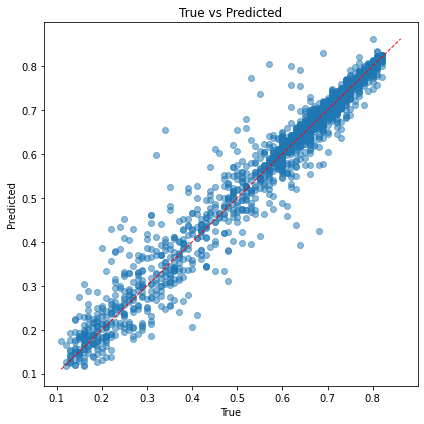


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-2.8332,0.0016,0.0291,0.1830
0.2-0.3,144,-3.8140,0.0041,0.0468,0.1934
0.3-0.4,131,-5.8559,0.0050,0.0514,0.1512
0.4-0.5,130,-2.6113,0.0037,0.0452,0.1001
0.5-0.6,180,-2.3287,0.0024,0.0316,0.0577
0.6-0.7,1009,0.2746,0.0007,0.0146,0.0224
0.7-0.8,1014,0.7312,0.0002,0.0080,0.0108
0.8-0.9,527,0.0830,0.0000,0.0033,0.0041



Average Segmented Metrics (skip NaN):
  R2:   -2.0443
  MSE:  0.0022
  MAE:  0.0288
  MAPE: 0.0903


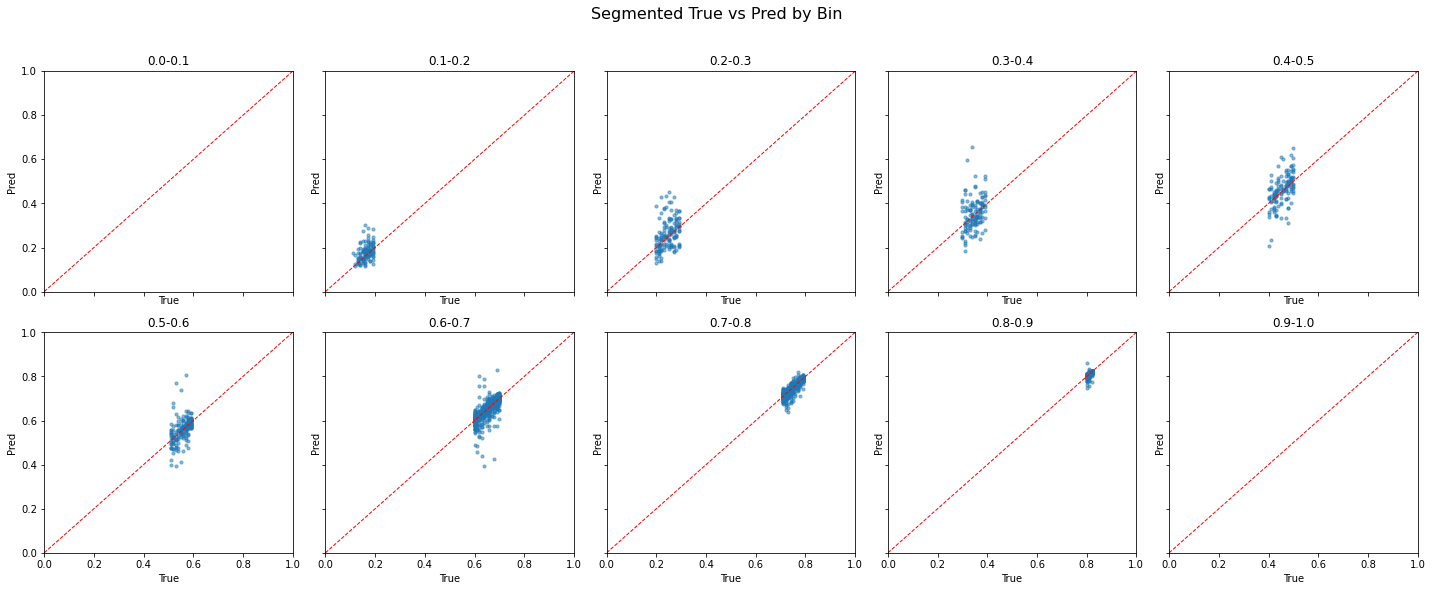

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# === 自定义 log-cosh loss ===
def log_cosh_loss(y_true, y_pred):
    return tf.reduce_mean(tf.math.log(tf.cosh(y_pred - y_true)))

# === 构建 Stacked LSTM 模型 ===
model_stacked_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),
    Dense(1)
])

# === 使用 log-cosh loss 编译模型 ===
model_stacked_lstm.compile(optimizer='adam', loss=log_cosh_loss)

# === 训练模型 ===
model_stacked_lstm.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# === 预测并评估 ===
y_pred_stacked = model_stacked_lstm.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_stacked)


Epoch 1/300
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing 

Epoch 102/300
407/407 - 4s - loss: 5.0006e-04 - 4s/epoch - 9ms/step
Epoch 103/300
407/407 - 3s - loss: 5.0336e-04 - 3s/epoch - 8ms/step
Epoch 104/300
407/407 - 5s - loss: 4.8474e-04 - 5s/epoch - 12ms/step
Epoch 105/300
407/407 - 5s - loss: 4.8705e-04 - 5s/epoch - 12ms/step
Epoch 106/300
407/407 - 3s - loss: 5.0267e-04 - 3s/epoch - 8ms/step
Epoch 107/300
407/407 - 3s - loss: 4.5184e-04 - 3s/epoch - 7ms/step
Epoch 108/300
407/407 - 3s - loss: 4.5994e-04 - 3s/epoch - 7ms/step
Epoch 109/300
407/407 - 3s - loss: 4.4732e-04 - 3s/epoch - 7ms/step
Epoch 110/300
407/407 - 3s - loss: 4.7345e-04 - 3s/epoch - 7ms/step
Epoch 111/300
407/407 - 3s - loss: 4.7130e-04 - 3s/epoch - 7ms/step
Epoch 112/300
407/407 - 3s - loss: 4.3446e-04 - 3s/epoch - 8ms/step
Epoch 113/300
407/407 - 3s - loss: 4.2273e-04 - 3s/epoch - 8ms/step
Epoch 114/300
407/407 - 3s - loss: 4.1653e-04 - 3s/epoch - 7ms/step
Epoch 115/300
407/407 - 3s - loss: 4.1387e-04 - 3s/epoch - 7ms/step
Epoch 116/300
407/407 - 4s - loss: 4.3223e-04 

Epoch 223/300
407/407 - 3s - loss: 1.2125e-04 - 3s/epoch - 8ms/step
Epoch 224/300
407/407 - 3s - loss: 1.2423e-04 - 3s/epoch - 7ms/step
Epoch 225/300
407/407 - 3s - loss: 1.4614e-04 - 3s/epoch - 7ms/step
Epoch 226/300
407/407 - 3s - loss: 1.5693e-04 - 3s/epoch - 7ms/step
Epoch 227/300
407/407 - 3s - loss: 1.5783e-04 - 3s/epoch - 7ms/step
Epoch 228/300
407/407 - 3s - loss: 1.5004e-04 - 3s/epoch - 7ms/step
Epoch 229/300
407/407 - 3s - loss: 1.3655e-04 - 3s/epoch - 7ms/step
Epoch 230/300
407/407 - 3s - loss: 1.2647e-04 - 3s/epoch - 7ms/step
Epoch 231/300
407/407 - 3s - loss: 1.6486e-04 - 3s/epoch - 8ms/step
Epoch 232/300
407/407 - 3s - loss: 1.3735e-04 - 3s/epoch - 7ms/step
Epoch 233/300
407/407 - 3s - loss: 1.4678e-04 - 3s/epoch - 7ms/step
Epoch 234/300
407/407 - 3s - loss: 1.2524e-04 - 3s/epoch - 8ms/step
Epoch 235/300
407/407 - 3s - loss: 1.3240e-04 - 3s/epoch - 7ms/step
Epoch 236/300
407/407 - 3s - loss: 1.2668e-04 - 3s/epoch - 7ms/step
Epoch 237/300
407/407 - 3s - loss: 1.2365e-04 - 

,Value
Metric,
MSE,0.0010
MAE,0.0164
MAPE,0.0385
R2,0.9664


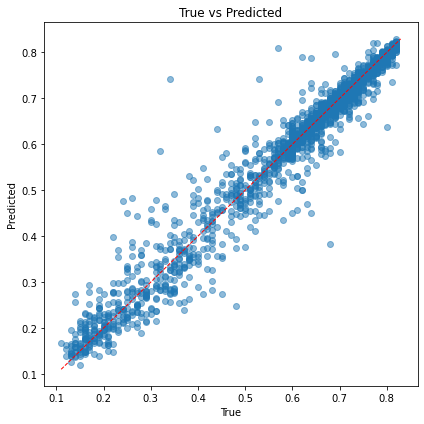


Segmented Metrics by True-Value Bin:


,Count,R2,MSE,MAE,MAPE
Interval,,,,,
0.0-0.1,0,nan,nan,nan,nan
0.1-0.2,116,-2.8337,0.0016,0.0292,0.1838
0.2-0.3,144,-2.9498,0.0034,0.0397,0.1616
0.3-0.4,131,-6.3393,0.0054,0.0513,0.1508
0.4-0.5,130,-2.8582,0.0040,0.0472,0.1053
0.5-0.6,180,-1.7536,0.0020,0.0289,0.0526
0.6-0.7,1009,0.2836,0.0007,0.0142,0.0219
0.7-0.8,1014,0.6541,0.0002,0.0092,0.0124
0.8-0.9,527,-1.0371,0.0001,0.0048,0.0060



Average Segmented Metrics (skip NaN):
  R2:   -2.1043
  MSE:  0.0022
  MAE:  0.0281
  MAPE: 0.0868


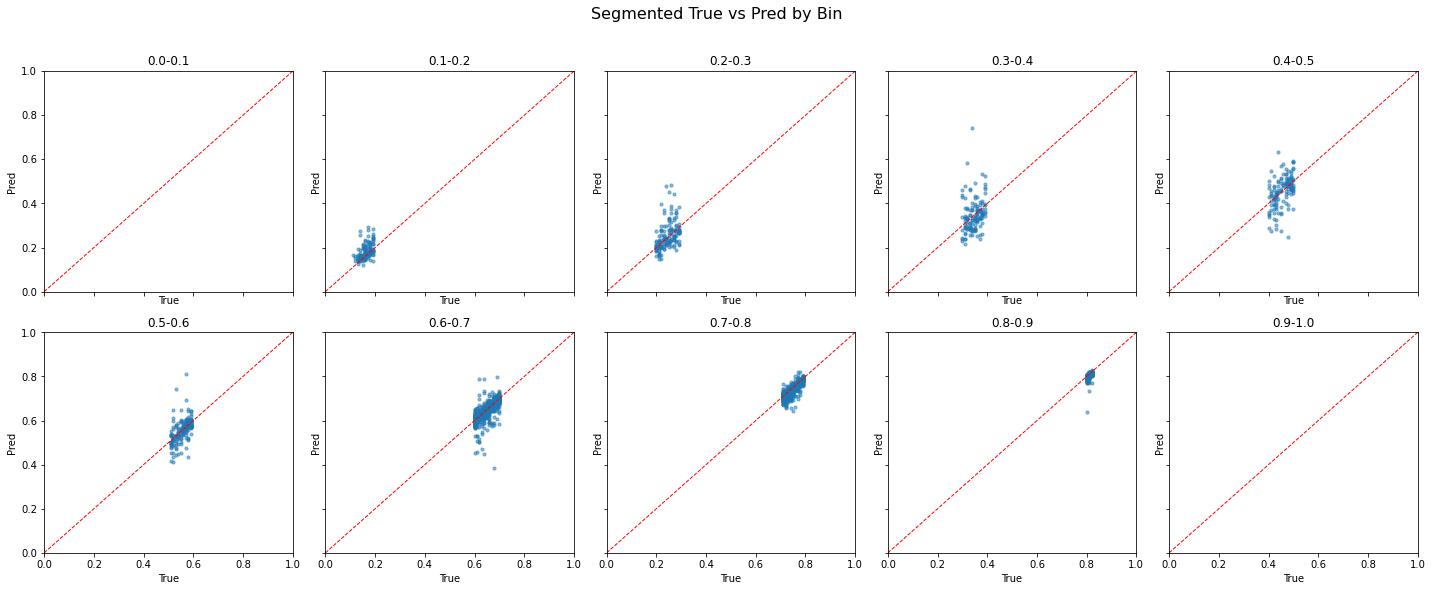

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# === 自定义 Weighted MSE Loss ===
def weighted_mse(y_true, y_pred):
    # 权重设计：值越小权重越大，这里用 1 / (y_true + ε) 形式
    epsilon = 1e-3  # 防止除以 0
    weights = 1.0 / (y_true + epsilon)
    squared_errors = tf.square(y_true - y_pred)
    weighted_errors = weights * squared_errors
    return tf.reduce_mean(weighted_errors)

# === 构建 Stacked LSTM 模型 ===
model_weighted = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),
    Dense(1)
])

# === 使用 Weighted MSE 编译模型 ===
model_weighted.compile(optimizer='adam', loss=weighted_mse)

# === 训练模型 ===
model_weighted.fit(
    X_seq_train, y_train,
    epochs=300, batch_size=32,
    verbose=2
)

# === 预测并评估 ===
y_pred_weighted = model_weighted.predict(X_seq_test).ravel()
evaluate_model(y_test, y_pred_weighted)
